# Machine Learning Assignment 2 & 3

**Dataset:** FIFA Players


## Created By
| Student Name                                     | Student ID   |
|--------------------------------------------------|--------------|
| Abdelrahman Ahmed Abdelhamid                     | 2406244856   |
| Omar Muhammad Muhammad Metwally                  | 2406241065   |
| Mahmoud Osama Elsayed Ebrahim                    | 2406241599   |
| Omar adel fathy                                  | 2406242653   |
| Adel George Adel                                 | 2406245614   |


## Imports & Global Settings

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold, StratifiedKFold, cross_validate
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)
from sklearn.pipeline import Pipeline

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42


---
## Task 1: Exploratory Data Analysis (EDA)

In [3]:
df = pd.read_csv("Fifa.csv")
print("Shape:", df.shape)
df.head()


Shape: (19667, 9)


,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


In [4]:
print("Dataset info:")
df.info()
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))
print("\nDuplicate rows:", df.duplicated().sum())


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  str    
 1   Country            19667 non-null  str    
 2   Position           19667 non-null  str    
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  str    
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 1.4 MB

Missing values:
Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

Duplicate rows: 0

Duplicate rows: 0


### Missing Values
> **Finding:** The cell above shows the missing-value count per column. We will impute or drop them during preprocessing.

In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']
Categorical columns: ['Name', 'Country', 'Position', 'Team']


### Distribution of `Value Per M$` — Skewness

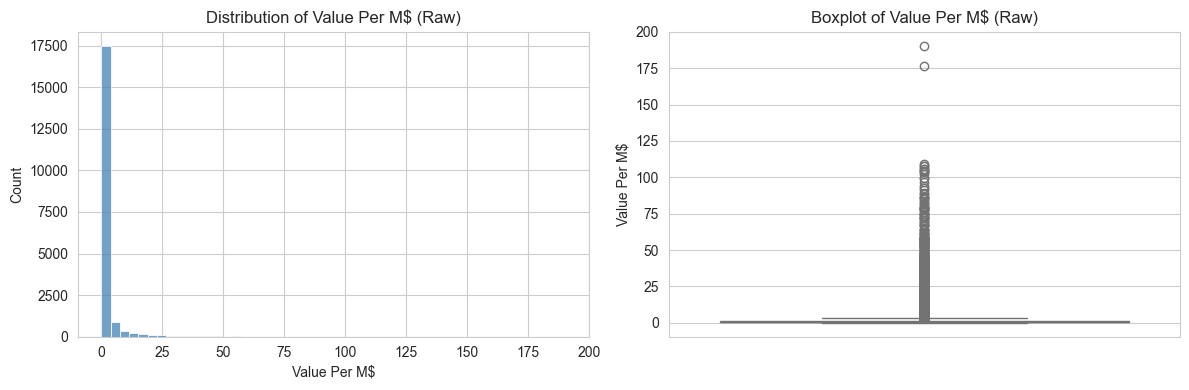

Skewness of 'Value Per M$': 7.9832


In [6]:
target_col = "Value Per M$"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[target_col].dropna(), bins=50, color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of Value Per M$ (Raw)")
axes[0].set_xlabel("Value Per M$")
sns.boxplot(y=df[target_col].dropna(), color="lightgreen", ax=axes[1])
axes[1].set_title("Boxplot of Value Per M$ (Raw)")
plt.tight_layout()
plt.show()

skewness = df[target_col].skew()
print(f"Skewness of 'Value Per M$': {skewness:.4f}")


**Skewness Interpretation:**  
The skewness (> 1) shows Value Per M$ is strongly right-skewed. A few elite players are outliers while the rest are on the lower end.


### Features Most Correlated with `Value Per M$`

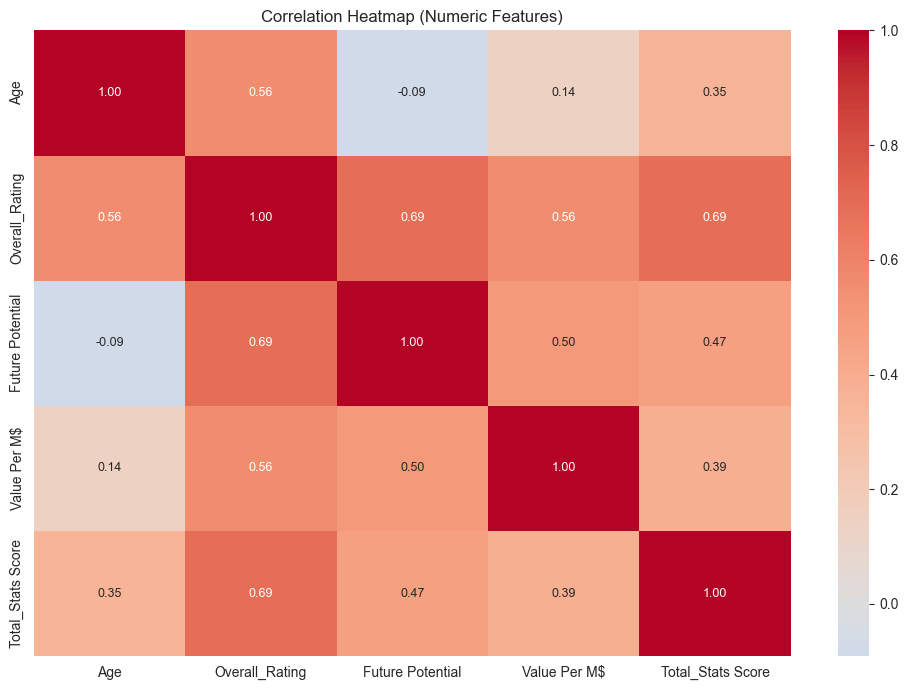

Correlation with 'Value Per M$':
Overall_Rating       0.561
Future Potential     0.501
Total_Stats Score    0.385
Age                  0.142
Name: Value Per M$, dtype: float64


In [7]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 9})
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

value_corr = corr[target_col].drop(target_col).sort_values(ascending=False)
print("Correlation with 'Value Per M$':")
print(value_corr.round(3))


**Answer — Which features are most related to `Value Per M$`?**

Based on the correlation matrix :

The top predictors for Value Per M$ based on the correlations are:

Overall_Rating & Future Potential: High ratings and potential drive value up.

Total_Stats Score: High skill totals are closely tied to market price.

Age: Younger, high-rated players tend to be more expensive.

I’m leaving Overall_Rating out of the classification model to avoid data leakage/circularity with the tier labels.

### Average `Overall_Rating` per `Position`

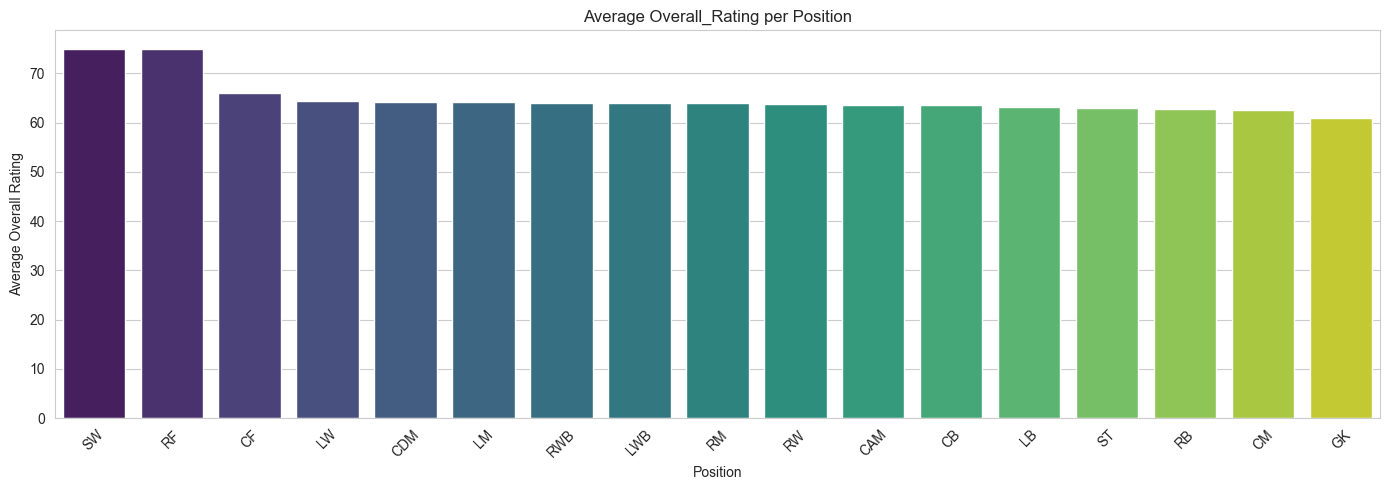

Position  Overall_Rating
      SW       75.000000
      RF       75.000000
      CF       66.042857
      LW       64.345979
     CDM       64.234168
      LM       64.172009
     RWB       64.063973
     LWB       64.043333
      RM       63.907731
      RW       63.718529
     CAM       63.679709
      CB       63.544448
      LB       63.276794
      ST       63.087505
      RB       62.863636
      CM       62.511767
      GK       60.987288


In [8]:
avg_rating_by_position = (
    df.groupby("Position")["Overall_Rating"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(14, 5))
sns.barplot(data=avg_rating_by_position, x="Position", y="Overall_Rating", palette="viridis")
plt.title("Average Overall_Rating per Position")
plt.xlabel("Position")
plt.ylabel("Average Overall Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(avg_rating_by_position.to_string(index=False))


**Finding:** The bar chart reveals which positions tend to have higher-rated players in this dataset. Goalkeepers (GK) and central defenders (CB) often cluster differently from attacking positions. This can influence classification balance and regression error if position-specific effects are large.


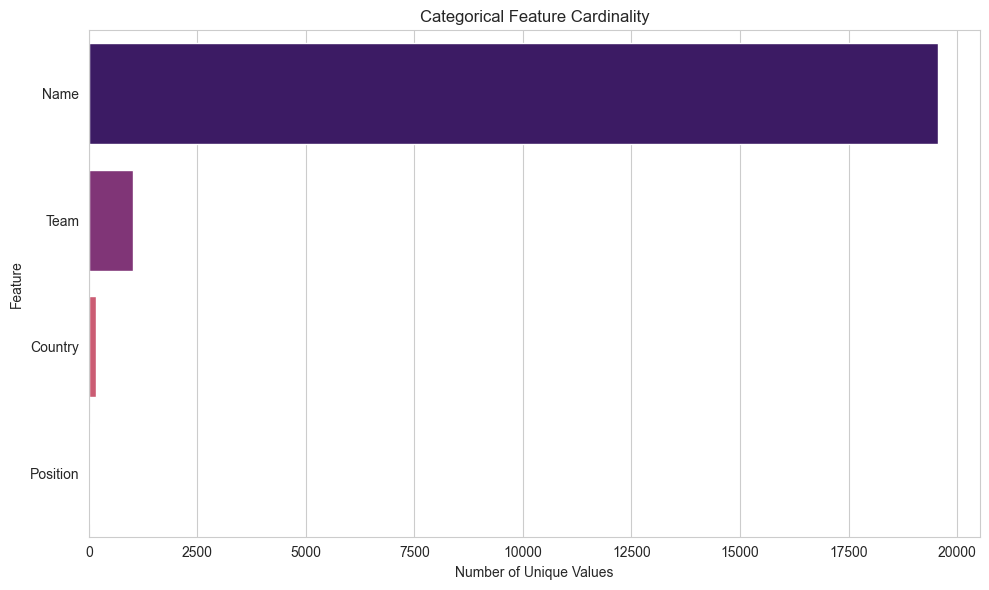

 feature  n_unique
    Name     19551
    Team      1009
 Country       164
Position        17


In [9]:
# --- Cardinality of categorical features ---
cat_cols = ['Name', 'Country', 'Position', 'Team']
cardinality_df = pd.DataFrame({
    'feature': cat_cols,
    'n_unique': [df[col].nunique() for col in cat_cols]
}).sort_values('n_unique', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=cardinality_df.head(15), x='n_unique', y='feature', palette='magma')
plt.title('Categorical Feature Cardinality')
plt.xlabel('Number of Unique Values')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# You can also print the cardinality values:
print(cardinality_df.to_string(index=False))

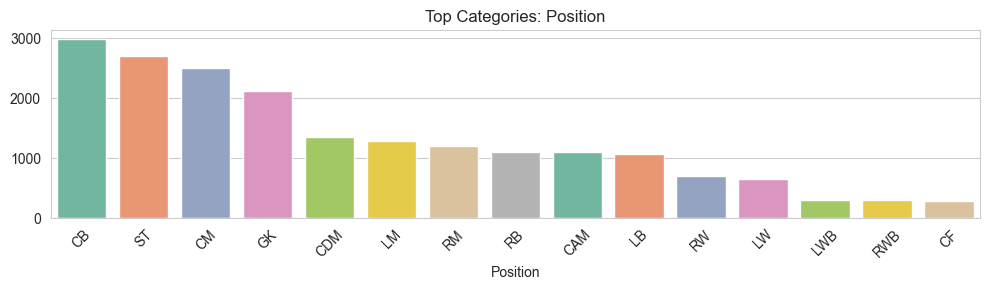

In [10]:
# Top categories for categorical features (excluding high-cardinality)
low_card = [c for c in categorical_cols if df[c].nunique() <= 30]
for col in low_card:
    vc = df[col].value_counts().head(15)
    plt.figure(figsize=(10, 3))
    sns.barplot(x=vc.index, y=vc.values, palette="Set2")
    plt.title(f"Top Categories: {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


---
## Task 2: Data Preprocessing

> All preprocessing steps are **fit on train data only** and then **applied to test data** 

In [11]:
# Drop high-cardinality identifier columns
df_clean = df.drop(columns=["Name", "Team", "Country"]).copy()
print("Shape after dropping identifiers:", df_clean.shape)
df_clean.head()


Shape after dropping identifiers: (19667, 6)


,Position,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
0,LW,30,68,68,0.65,1660
1,GK,35,67,67,0.35,1620
2,GK,28,63,65,0.20,1480
3,CB,32,68,68,0.50,1695
4,CB,30,66,66,0.40,1640


In [12]:
target_col = "Value Per M$"
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Target — min: {y_train.min():.2f}, max: {y_train.max():.2f}, mean: {y_train.mean():.2f}")


Train: (15733, 5)  |  Test: (3934, 5)
Target — min: 0.00, max: 176.50, mean: 2.49


In [13]:
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
print(f"Numerical  ({len(num_cols)}): {num_cols}")
print(f"Categorical ({len(cat_cols)}): {cat_cols}")

# --- Imputation (fit on train only) ---
num_imputer = SimpleImputer(strategy="median")
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols]  = num_imputer.transform(X_test[num_cols])

if cat_cols:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
    X_test[cat_cols]  = cat_imputer.transform(X_test[cat_cols])

print("Missing after imputation (train):", X_train.isnull().sum().sum())
print("Missing after imputation (test) :", X_test.isnull().sum().sum())


Numerical  (4): ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
Categorical (1): ['Position']
Missing after imputation (train): 0
Missing after imputation (test) : 0
Missing after imputation (test) : 0


In [14]:
# --- Outlier capping via IQR (bounds from train only) ---
def cap_outliers_iqr(train_df, test_df, col):
    Q1, Q3 = train_df[col].quantile(0.25), train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_tr = ((train_df[col] < lo) | (train_df[col] > hi)).sum()
    n_te = ((test_df[col] < lo)  | (test_df[col] > hi)).sum()
    train_df[col] = train_df[col].clip(lo, hi)
    test_df[col]  = test_df[col].clip(lo, hi)
    return n_tr, n_te

for c in num_cols:
    n_tr, n_te = cap_outliers_iqr(X_train, X_test, c)
    print(f"  {c}: {n_tr} train / {n_te} test outliers capped")

# Cap target
Q1, Q3 = y_train.quantile(0.25), y_train.quantile(0.75)
IQR = Q3 - Q1
lo_y, hi_y = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
y_train = y_train.clip(lo_y, hi_y)
y_test  = y_test.clip(lo_y, hi_y)
print(f"  Target: capped to [{lo_y:.2f}, {hi_y:.2f}]")


  Age: 129 train / 40 test outliers capped
  Overall_Rating: 111 train / 35 test outliers capped
  Future Potential: 94 train / 26 test outliers capped
  Total_Stats Score: 666 train / 158 test outliers capped
  Target: capped to [-1.59, 3.51]


In [15]:
# --- One-Hot Encoding (fit on train only) ---
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe.fit(X_train[cat_cols])

ohe_train = pd.DataFrame(
    ohe.transform(X_train[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train.index
)
ohe_test = pd.DataFrame(
    ohe.transform(X_test[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_test.index
)

X_train_enc = pd.concat([X_train[num_cols].reset_index(drop=True),
                          ohe_train.reset_index(drop=True)], axis=1)
X_test_enc  = pd.concat([X_test[num_cols].reset_index(drop=True),
                          ohe_test.reset_index(drop=True)], axis=1)

print("After OHE — Train:", X_train_enc.shape, " | Test:", X_test_enc.shape)


After OHE — Train: (15733, 21)  | Test: (3934, 21)
 (15733, 21)  | Test: (3934, 21)


In [16]:
# --- Standard Scaling (fit on train only) ---
scaler_reg = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler_reg.fit_transform(X_train_enc),
    columns=X_train_enc.columns
)
X_test_scaled = pd.DataFrame(
    scaler_reg.transform(X_test_enc),
    columns=X_test_enc.columns
)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape :", X_test_scaled.shape)
print("\nPreprocessing complete — no data leakage!")
X_train_scaled.head(3)


Scaled train shape: (15733, 21)
Scaled test shape : (3934, 21)

Preprocessing complete — no data leakage!


,Age,Overall_Rating,Future Potential,Total_Stats Score,Position_CAM,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,...,Position_LM,Position_LW,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW
0,0.435531,0.489099,-0.102944,0.550469,-0.245015,-0.422286,-0.274578,-0.119635,-0.377017,-0.351147,...,-0.264539,5.446890,-0.12525,-0.242381,-0.011276,-0.255342,-0.192291,-0.12525,-0.398173,-0.007973
1,-0.858009,-1.063694,-0.412772,-0.660739,-0.245015,-0.422286,-0.274578,-0.119635,-0.377017,-0.351147,...,-0.264539,-0.183591,-0.12525,-0.242381,-0.011276,-0.255342,-0.192291,-0.12525,2.511469,-0.007973
2,1.944660,1.524295,0.671625,1.840512,-0.245015,-0.422286,-0.274578,-0.119635,-0.377017,-0.351147,...,-0.264539,-0.183591,-0.12525,-0.242381,-0.011276,-0.255342,5.200439,-0.12525,-0.398173,-0.007973


---
## Task 3: Create Classification Target

We bin players into **four performance tiers** based on `Overall_Rating` using quartile boundaries.

**Tier labels (per assignment specification):** Low / Mid / High / Elite


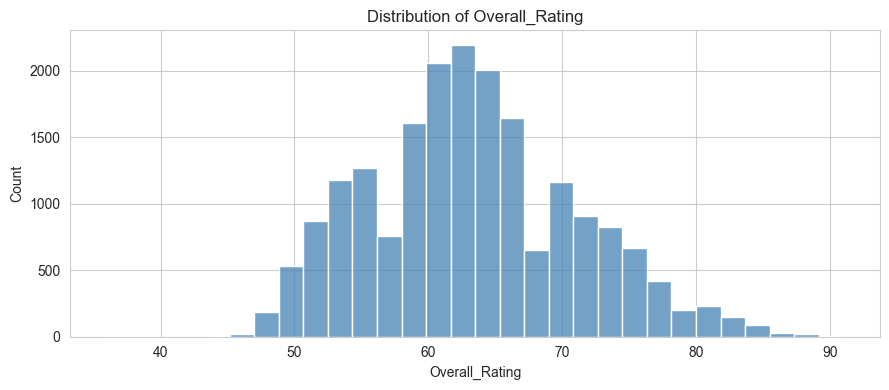

Q1 (25th pct): 58.00  → boundary between Low and Mid
Q2 (50th pct): 63.00  → boundary between Mid and High
Q3 (75th pct): 68.00  → boundary between High and Elite


In [17]:
rating_col = "Overall_Rating"
plt.figure(figsize=(9, 4))
sns.histplot(df_clean[rating_col], bins=30, color="steelblue")
plt.title("Distribution of Overall_Rating")
plt.xlabel("Overall_Rating")
plt.tight_layout()
plt.show()

q1 = df_clean[rating_col].quantile(0.25)
q2 = df_clean[rating_col].quantile(0.50)
q3 = df_clean[rating_col].quantile(0.75)

print(f"Q1 (25th pct): {q1:.2f}  → boundary between Low and Mid")
print(f"Q2 (50th pct): {q2:.2f}  → boundary between Mid and High")
print(f"Q3 (75th pct): {q3:.2f}  → boundary between High and Elite")


**Threshold Justification:**  
Using data-driven quartile boundaries ensures each tier contains approximately 25% of players, making the classes roughly balanced. This avoids arbitrary domain thresholds and aligns with the data distribution.


In [18]:
def assign_tier(val, q1, q2, q3):
    if val <= q1:   return "Low"
    elif val <= q2: return "Mid"
    elif val <= q3: return "High"
    else:           return "Elite"

classification_data = df_clean.copy()
classification_data["Performance_Tier"] = classification_data[rating_col].apply(
    lambda x: assign_tier(x, q1, q2, q3)
)

tier_order = ["Low", "Mid", "High", "Elite"]
print("Full dataset class counts:")
print(classification_data["Performance_Tier"].value_counts()[tier_order])


Full dataset class counts:
Performance_Tier
Low      5568
Mid      5102
High     4297
Elite    4700
Name: count, dtype: int64


In [19]:
# Stratified split — keep Overall_Rating OUT of features (leakage)
feat_cls = classification_data.drop(columns=["Performance_Tier", "Overall_Rating"])
tgt_cls  = classification_data["Performance_Tier"]

X_tr_cls, X_te_cls, y_tr_cls, y_te_cls = train_test_split(
    feat_cls, tgt_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=tgt_cls
)
print(f"Train: {X_tr_cls.shape}  |  Test: {X_te_cls.shape}")
print("\nTrain class counts:")
print(y_tr_cls.value_counts()[tier_order])
print("\nTest class counts:")
print(y_te_cls.value_counts()[tier_order])


Train: (15733, 5)  |  Test: (3934, 5)

Train class counts:
Performance_Tier
Low      4454
Mid      4081
High     3438
Elite    3760
Name: count, dtype: int64

Test class counts:
Performance_Tier
Low      1114
Mid      1021
High      859
Elite     940
Name: count, dtype: int64


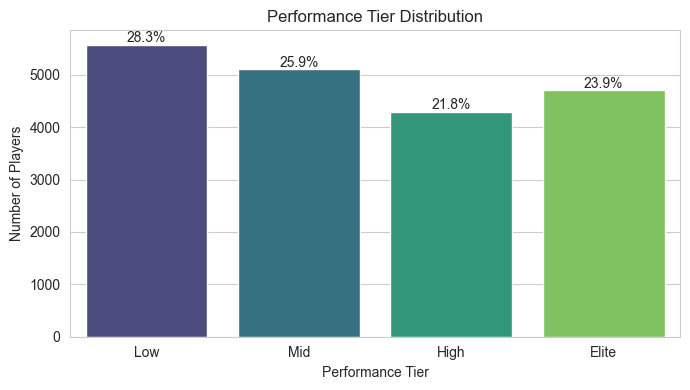

Imbalance gap: 0.0646
Conclusion: Distribution is relatively balanced (quartile-based tiers).


In [20]:
counts = classification_data["Performance_Tier"].value_counts()[tier_order]
ratios = counts / counts.sum()

plt.figure(figsize=(7, 4))
sns.barplot(x=counts.index, y=counts.values, palette="viridis", order=tier_order)
for i, (v, r) in enumerate(zip(counts.values, ratios.values)):
    plt.text(i, v + 50, f"{r*100:.1f}%", ha="center", fontsize=10)
plt.title("Performance Tier Distribution")
plt.xlabel("Performance Tier")
plt.ylabel("Number of Players")
plt.tight_layout()
plt.show()

gap = ratios.max() - ratios.min()
print(f"Imbalance gap: {gap:.4f}")
if gap < 0.10:
    print("Conclusion: Distribution is relatively balanced (quartile-based tiers).")
else:
    print("Conclusion: Distribution shows some imbalance — monitor per-class metrics.")


---
## Task 4: Model 1 — Polynomial Regression

**Goal:** Predict `Value Per M$` using progressively complex polynomial features on numeric columns only.


In [21]:
# Identify numeric and OHE columns in the scaled dataset
ohe_cols = [c for c in X_train_scaled.columns if c not in num_cols]
print(f"Numeric features ({len(num_cols)}): {num_cols}")
print(f"OHE features: {len(ohe_cols)}")


Numeric features (4): ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
OHE features: 17


### Baseline Linear Regression

In [22]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

def evaluate_regression(model, X_tr, X_te, y_tr, y_te, label="Model"):
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)
    results = {}
    for split, y_true, y_pred in [("Train", y_tr, y_tr_pred), ("Test", y_te, y_te_pred)]:
        results[split] = {
            "MAE":  mean_absolute_error(y_true, y_pred),
            "MSE":  mean_squared_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "R²":   r2_score(y_true, y_pred),
        }
    df_res = pd.DataFrame(results).T
    print(f"\n{'='*40}")
    print(f"{label}")
    print('='*40)
    print(df_res.round(4))
    return df_res, model.predict(X_te)

lr_results, _ = evaluate_regression(lr, X_train_scaled, X_test_scaled, y_train, y_test, "Linear Regression (Baseline)")



Linear Regression (Baseline)
          MAE     MSE    RMSE      R²
Train  0.3777  0.2482  0.4982  0.8038
Test   0.3765  0.2426  0.4926  0.8106


### Polynomial Features (degree 1–4) on Numeric Features Only

In [23]:
degree_results = []
best_poly_degree = 1
best_gap = float('inf')          # track smallest absolute gap

# Store for later use in regularization
poly_train_best = None
poly_test_best  = None

for deg in [1, 2, 3, 4]:
    pf = PolynomialFeatures(degree=deg, include_bias=False)

    # Apply only to numeric columns
    X_tr_num_poly = pf.fit_transform(X_train_scaled[num_cols])
    X_te_num_poly = pf.transform(X_test_scaled[num_cols])

    # Combine with OHE columns (no poly expansion)
    X_tr_ohe = X_train_scaled[ohe_cols].values
    X_te_ohe = X_test_scaled[ohe_cols].values

    X_tr_poly = np.hstack([X_tr_num_poly, X_tr_ohe])
    X_te_poly = np.hstack([X_te_num_poly, X_te_ohe])

    model = LinearRegression()
    model.fit(X_tr_poly, y_train)

    tr_r2   = r2_score(y_train, model.predict(X_tr_poly))
    te_r2   = r2_score(y_test,  model.predict(X_te_poly))
    gap     = tr_r2 - te_r2
    tr_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_tr_poly)))
    te_rmse = np.sqrt(mean_squared_error(y_test,  model.predict(X_te_poly)))

    degree_results.append({
        "Degree": deg,
        "Train R²": tr_r2, "Test R²": te_r2,
        "Train RMSE": tr_rmse, "Test RMSE": te_rmse,
        "Gap R²": gap
    })
    print(f"Degree {deg}: Train R²={tr_r2:.4f}  Test R²={te_r2:.4f}  Gap={gap:.4f}  Train RMSE={tr_rmse:.4f}  Test RMSE={te_rmse:.4f}")

    # Select degree that minimises the absolute gap (optimal generalisation)
    if abs(gap) < best_gap:
        best_gap = abs(gap)
        best_poly_degree = deg
        poly_train_best   = X_tr_poly.copy()
        poly_test_best    = X_te_poly.copy()

deg_df = pd.DataFrame(degree_results)
print(f"\nBest degree (minimum train-test gap): {best_poly_degree} (Gap = {best_gap:.4f})")

Degree 1: Train R²=0.8038  Test R²=0.8106  Gap=-0.0068  Train RMSE=0.4982  Test RMSE=0.4926
Degree 2: Train R²=0.8571  Test R²=0.8657  Gap=-0.0086  Train RMSE=0.4252  Test RMSE=0.4148
Degree 3: Train R²=0.9028  Test R²=0.9037  Gap=-0.0009  Train RMSE=0.3506  Test RMSE=0.3512
Degree 4: Train R²=0.9280  Test R²=0.9200  Gap=0.0079  Train RMSE=0.3018  Test RMSE=0.3200

Best degree (minimum train-test gap): 3 (Gap = 0.0009)


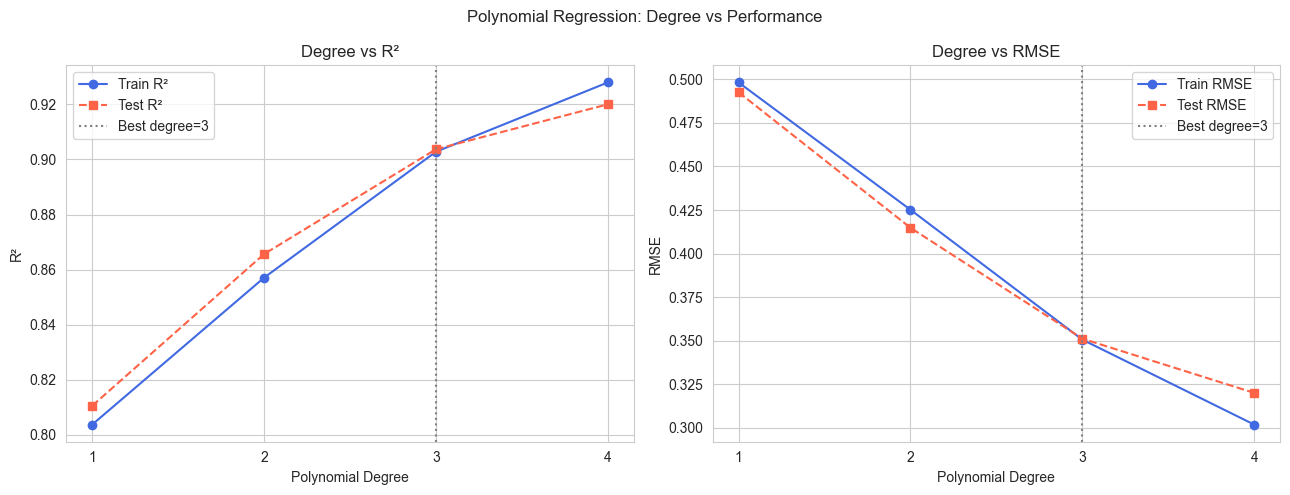

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(deg_df["Degree"], deg_df["Train R²"], "o-", label="Train R²", color="royalblue")
axes[0].plot(deg_df["Degree"], deg_df["Test R²"],  "s--", label="Test R²",  color="tomato")
axes[0].axvline(best_poly_degree, color="gray", linestyle=":", label=f"Best degree={best_poly_degree}")
axes[0].set_title("Degree vs R²")
axes[0].set_xlabel("Polynomial Degree")
axes[0].set_ylabel("R²")
axes[0].legend()
axes[0].set_xticks([1, 2, 3, 4])

axes[1].plot(deg_df["Degree"], deg_df["Train RMSE"], "o-", label="Train RMSE", color="royalblue")
axes[1].plot(deg_df["Degree"], deg_df["Test RMSE"],  "s--", label="Test RMSE",  color="tomato")
axes[1].axvline(best_poly_degree, color="gray", linestyle=":", label=f"Best degree={best_poly_degree}")
axes[1].set_title("Degree vs RMSE")
axes[1].set_xlabel("Polynomial Degree")
axes[1].set_ylabel("RMSE")
axes[1].legend()
axes[1].set_xticks([1, 2, 3, 4])

plt.suptitle("Polynomial Regression: Degree vs Performance")
plt.tight_layout()
plt.show()


**Observation:** As degree increases, Train R² typically rises while Test R² may plateau or drop — classic overfitting. The best generalization is the degree where the **Train/Test gap is smallest** while Test R² is highest. Higher degrees produce many interaction terms from numeric features, rapidly inflating variance.


### Ridge Regression (L2 Regularization)

In [25]:
alphas = np.logspace(-3, 3, 30)
ridge_results = []

for a in alphas:
    ridge = Ridge(alpha=a, random_state=RANDOM_STATE)
    ridge.fit(poly_train_best, y_train)
    tr_rmse = np.sqrt(mean_squared_error(y_train, ridge.predict(poly_train_best)))
    te_rmse = np.sqrt(mean_squared_error(y_test,  ridge.predict(poly_test_best)))
    tr_r2   = r2_score(y_train, ridge.predict(poly_train_best))
    te_r2   = r2_score(y_test,  ridge.predict(poly_test_best))
    ridge_results.append({"alpha": a, "Train RMSE": tr_rmse, "Test RMSE": te_rmse,
                           "Train R²": tr_r2, "Test R²": te_r2})

ridge_df = pd.DataFrame(ridge_results)
best_ridge_idx = ridge_df["Test RMSE"].idxmin()
best_ridge_alpha = ridge_df.loc[best_ridge_idx, "alpha"]
best_ridge_rmse  = ridge_df.loc[best_ridge_idx, "Test RMSE"]

print(f"Best Ridge alpha: {best_ridge_alpha:.6f}  |  Test RMSE: {best_ridge_rmse:.4f}")


Best Ridge alpha: 13.738238  |  Test RMSE: 0.3437


### Lasso Regression (L1 Regularization)

In [26]:
lasso_results = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000, random_state=RANDOM_STATE)
    lasso.fit(poly_train_best, y_train)
    tr_rmse = np.sqrt(mean_squared_error(y_train, lasso.predict(poly_train_best)))
    te_rmse = np.sqrt(mean_squared_error(y_test,  lasso.predict(poly_test_best)))
    tr_r2   = r2_score(y_train, lasso.predict(poly_train_best))
    te_r2   = r2_score(y_test,  lasso.predict(poly_test_best))
    lasso_results.append({"alpha": a, "Train RMSE": tr_rmse, "Test RMSE": te_rmse,
                           "Train R²": tr_r2, "Test R²": te_r2})

lasso_df = pd.DataFrame(lasso_results)
best_lasso_idx   = lasso_df["Test RMSE"].idxmin()
best_lasso_alpha = lasso_df.loc[best_lasso_idx, "alpha"]
best_lasso_rmse  = lasso_df.loc[best_lasso_idx, "Test RMSE"]

print(f"Best Lasso alpha: {best_lasso_alpha:.6f}  |  Test RMSE: {best_lasso_rmse:.4f}")


Best Lasso alpha: 0.001000  |  Test RMSE: 0.3438


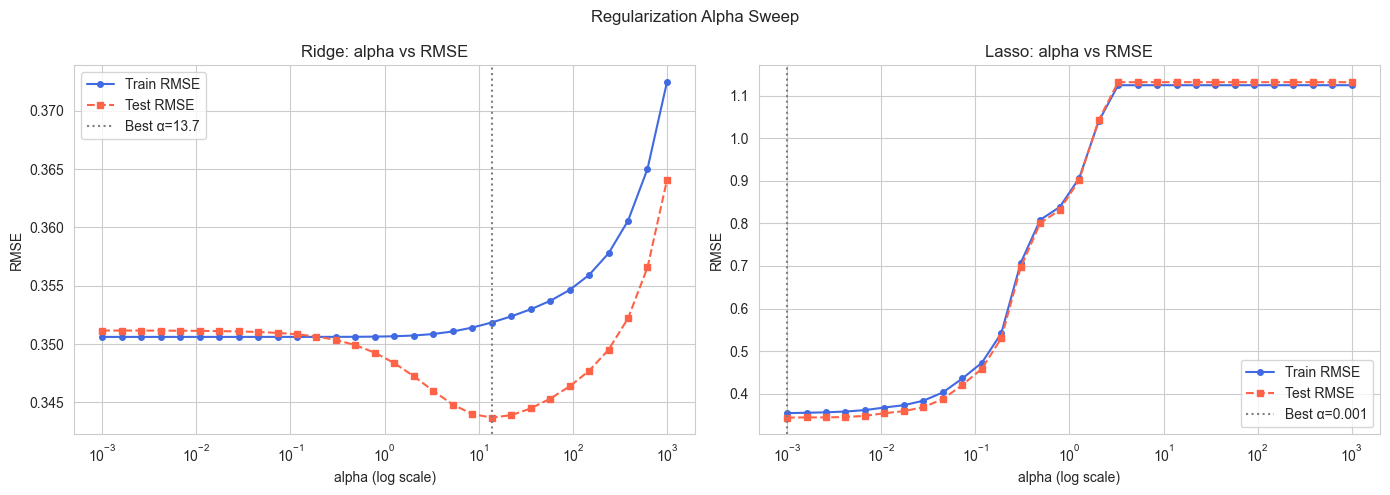

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge plot
axes[0].semilogx(ridge_df["alpha"], ridge_df["Train RMSE"], "o-", label="Train RMSE", color="royalblue", markersize=4)
axes[0].semilogx(ridge_df["alpha"], ridge_df["Test RMSE"],  "s--", label="Test RMSE",  color="tomato", markersize=4)
axes[0].axvline(best_ridge_alpha, color="gray", linestyle=":", label=f"Best α={best_ridge_alpha:.3g}")
axes[0].set_title("Ridge: alpha vs RMSE")
axes[0].set_xlabel("alpha (log scale)")
axes[0].set_ylabel("RMSE")
axes[0].legend()

# Lasso plot
axes[1].semilogx(lasso_df["alpha"], lasso_df["Train RMSE"], "o-", label="Train RMSE", color="royalblue", markersize=4)
axes[1].semilogx(lasso_df["alpha"], lasso_df["Test RMSE"],  "s--", label="Test RMSE",  color="tomato", markersize=4)
axes[1].axvline(best_lasso_alpha, color="gray", linestyle=":", label=f"Best α={best_lasso_alpha:.3g}")
axes[1].set_title("Lasso: alpha vs RMSE")
axes[1].set_xlabel("alpha (log scale)")
axes[1].set_ylabel("RMSE")
axes[1].legend()

plt.suptitle("Regularization Alpha Sweep")
plt.tight_layout()
plt.show()


### Ridge vs Lasso Comparison & Lasso Feature Selection

In [28]:
# Fit best Ridge
best_ridge = Ridge(alpha=best_ridge_alpha, random_state=RANDOM_STATE)
best_ridge.fit(poly_train_best, y_train)
ridge_results_final, _ = evaluate_regression(
    best_ridge, poly_train_best, poly_test_best, y_train, y_test,
    f"Ridge (alpha={best_ridge_alpha:.4g}, degree={best_poly_degree})")

# Fit best Lasso
best_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000, random_state=RANDOM_STATE)
best_lasso.fit(poly_train_best, y_train)
lasso_results_final, _ = evaluate_regression(
    best_lasso, poly_train_best, poly_test_best, y_train, y_test,
    f"Lasso (alpha={best_lasso_alpha:.4g}, degree={best_poly_degree})")



Ridge (alpha=13.74, degree=3)
          MAE     MSE    RMSE      R²
Train  0.2205  0.1238  0.3518  0.9021
Test   0.2216  0.1181  0.3437  0.9078

Lasso (alpha=0.001, degree=3)
          MAE     MSE    RMSE      R²
Train  0.2209  0.1255  0.3542  0.9008
Test   0.2213  0.1182  0.3438  0.9077


In [29]:
# Lasso zeroed-out feature inspection
lasso_coef = best_lasso.coef_
n_zero   = (lasso_coef == 0).sum()
n_nonzero = (lasso_coef != 0).sum()
total = len(lasso_coef)

print(f"Total features after polynomial expansion: {total}")
print(f"Features zeroed out by Lasso: {n_zero} ({100*n_zero/total:.1f}%)")
print(f"Features kept by Lasso:       {n_nonzero} ({100*n_nonzero/total:.1f}%)")

if n_zero > 0:
    print("\nSample of zeroed-out feature indices (first 20):")
    print(np.where(lasso_coef == 0)[0][:20])
else:
    print("\nLasso did not zero out any features at this alpha — try a larger alpha for sparsity.")


Total features after polynomial expansion: 51
Features zeroed out by Lasso: 6 (11.8%)
Features kept by Lasso:       45 (88.2%)

Sample of zeroed-out feature indices (first 20):
[ 5 11 21 22 28 35]


**Lasso Feature Selection:** Lasso (L1) applies a penalty that drives some coefficients **exactly to zero**, performing automatic feature selection. This is especially visible at higher alpha values. If Lasso zeros out features, those are deemed non-informative for predicting `Value Per M$` once other features are present.

**Ridge vs Lasso:**
- **Ridge** shrinks all coefficients toward zero but rarely sets them exactly to zero — it retains all features, distributing importance smoothly.  
- **Lasso** produces sparse models by zeroing weak features.  
- In datasets with many OHE binary features, Ridge often outperforms Lasso because OHE columns form groups where each individual column carries partial signal — Lasso may incorrectly zero some of them while Ridge keeps all at reduced weight.


---
## Task 5: Model 2 — Logistic Regression

**Target:** `Performance_Tier` (Low / Mid / High / Elite)  
**Note:** `Overall_Rating` is **excluded** from features to avoid data leakage (it was used to define the tiers).


In [30]:
# Prepare classification features (OHE + Scale — both leak-free)
X_tr_raw = X_tr_cls.copy()
X_te_raw = X_te_cls.copy()

# OHE categorical features (fit on train only)
cat_cls = X_tr_raw.select_dtypes(include="object").columns.tolist()
num_cls = X_tr_raw.select_dtypes(include=np.number).columns.tolist()

ohe_cls = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe_cls.fit(X_tr_raw[cat_cls])

def ohe_and_scale(X_tr, X_te, num_c, cat_c, ohe, scaler=None, fit_scaler=True):
    ohe_tr = pd.DataFrame(ohe.transform(X_tr[cat_c]),
                           columns=ohe.get_feature_names_out(cat_c), index=X_tr.index)
    ohe_te = pd.DataFrame(ohe.transform(X_te[cat_c]),
                           columns=ohe.get_feature_names_out(cat_c), index=X_te.index)
    X_tr_f = pd.concat([X_tr[num_c].reset_index(drop=True), ohe_tr.reset_index(drop=True)], axis=1)
    X_te_f = pd.concat([X_te[num_c].reset_index(drop=True), ohe_te.reset_index(drop=True)], axis=1)
    if scaler is None:
        scaler = StandardScaler()
    if fit_scaler:
        X_tr_f = pd.DataFrame(scaler.fit_transform(X_tr_f), columns=X_tr_f.columns)
        X_te_f = pd.DataFrame(scaler.transform(X_te_f),     columns=X_te_f.columns)
    return X_tr_f, X_te_f, scaler

scaler_cls = StandardScaler()
X_tr_cls_scaled, X_te_cls_scaled, scaler_cls = ohe_and_scale(
    X_tr_raw, X_te_raw, num_cls, cat_cls, ohe_cls, scaler_cls)

print("Classification train shape:", X_tr_cls_scaled.shape)
print("Classification test shape: ", X_te_cls_scaled.shape)


Classification train shape: (15733, 21)
Classification test shape:  (3934, 21)


### Baseline Logistic Regression

In [31]:
tier_order = ["Low", "Mid", "High", "Elite"]

baseline_lr = LogisticRegression(penalty="l2", C=1.0, solver="lbfgs",
                                  max_iter=5000, random_state=RANDOM_STATE)
baseline_lr.fit(X_tr_cls_scaled, y_tr_cls)
y_pred_base = baseline_lr.predict(X_te_cls_scaled)

print(f"Baseline Accuracy: {accuracy_score(y_te_cls, y_pred_base):.4f}")
print("\nClassification Report:")
print(classification_report(y_te_cls, y_pred_base, target_names=tier_order, zero_division=0))


Baseline Accuracy: 0.8335

Classification Report:
              precision    recall  f1-score   support

         Low       0.92      0.90      0.91       940
         Mid       0.79      0.76      0.77       859
        High       0.87      0.89      0.88      1114
       Elite       0.75      0.77      0.76      1021

    accuracy                           0.83      3934
   macro avg       0.83      0.83      0.83      3934
weighted avg       0.83      0.83      0.83      3934



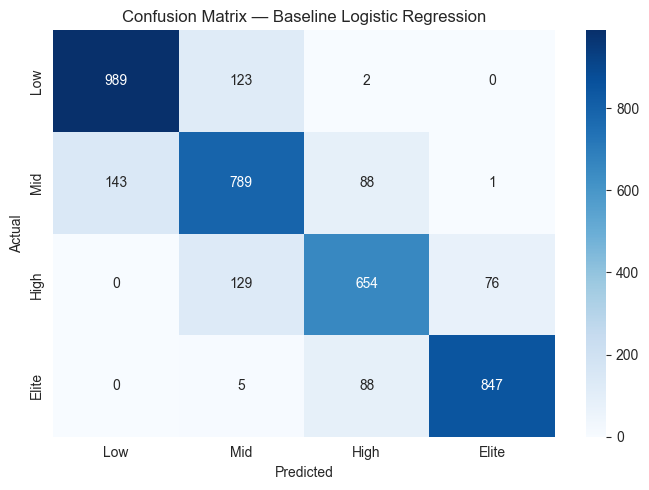

In [32]:
cm = confusion_matrix(y_te_cls, y_pred_base, labels=tier_order)
plt.figure(figsize=(7, 5))
sns.heatmap(pd.DataFrame(cm, index=tier_order, columns=tier_order),
            annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Baseline Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


**Confusion Matrix Explanation:**  
- Diagonal cells = correct predictions per tier.  
- Off-diagonal cells = misclassifications (e.g., predicting "Mid" when actual was "High").  
- Adjacent tiers (e.g., Mid vs High) are harder to distinguish because `Overall_Rating` boundaries between them are data-driven quartiles — players near the boundary can look similar.


### C-Value Sweep (Regularization Strength)

In [33]:
c_grid = np.logspace(-3, 3, 15)
c_results = []

for c in c_grid:
    clf = LogisticRegression(penalty="l2", C=c, solver="saga",
                              max_iter=2000, tol=1e-3, random_state=RANDOM_STATE)
    clf.fit(X_tr_cls_scaled, y_tr_cls)
    c_results.append({
        "C": c,
        "Train Accuracy": accuracy_score(y_tr_cls, clf.predict(X_tr_cls_scaled)),
        "Test Accuracy":  accuracy_score(y_te_cls, clf.predict(X_te_cls_scaled))
    })

c_df = pd.DataFrame(c_results)
best_c = c_df.loc[c_df["Test Accuracy"].idxmax(), "C"]
print(f"Best C: {best_c:.6g}")
print(c_df.round(4).to_string(index=False))


Best C: 0.372759
        C  Train Accuracy  Test Accuracy
   0.0010          0.7461         0.7300
   0.0027          0.7780         0.7636
   0.0072          0.7967         0.7824
   0.0193          0.8053         0.7883
   0.0518          0.8079         0.7936
   0.1389          0.8096         0.7982
   0.3728          0.8116         0.8005
   1.0000          0.8129         0.7997
   2.6827          0.8131         0.7994
   7.1969          0.8134         0.7994
  19.3070          0.8136         0.7994
  51.7947          0.8136         0.7994
 138.9495          0.8136         0.7994
 372.7594          0.8136         0.7994
1000.0000          0.8136         0.7994


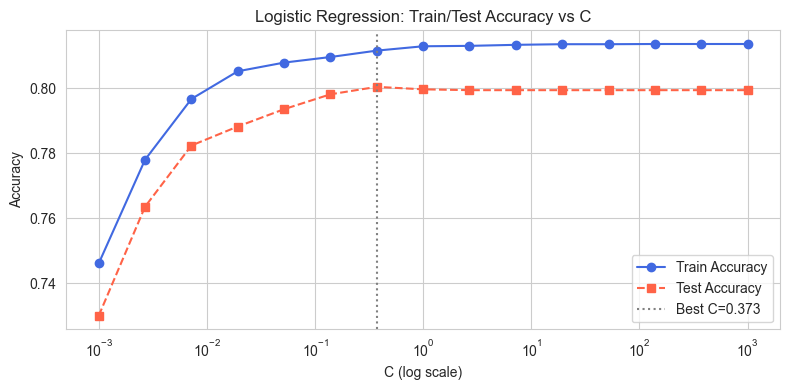

In [34]:
plt.figure(figsize=(8, 4))
plt.semilogx(c_df["C"], c_df["Train Accuracy"], "o-", label="Train Accuracy", color="royalblue")
plt.semilogx(c_df["C"], c_df["Test Accuracy"],  "s--", label="Test Accuracy",  color="tomato")
plt.axvline(best_c, color="gray", linestyle=":", label=f"Best C={best_c:.3g}")
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("Logistic Regression: Train/Test Accuracy vs C")
plt.legend()
plt.tight_layout()
plt.show()


### L1 vs L2 Regularization Comparison

In [35]:
clf_l1 = LogisticRegression(penalty="l1", C=best_c, solver="saga",
                             max_iter=5000, random_state=RANDOM_STATE)
clf_l2 = LogisticRegression(penalty="l2", C=best_c, solver="lbfgs",
                             max_iter=5000, random_state=RANDOM_STATE)

clf_l1.fit(X_tr_cls_scaled, y_tr_cls)
clf_l2.fit(X_tr_cls_scaled, y_tr_cls)

y_pred_l1 = clf_l1.predict(X_te_cls_scaled)
y_pred_l2 = clf_l2.predict(X_te_cls_scaled)

comparison = pd.DataFrame([
    {"Regularization": "L1 (saga)",  "C": best_c, "Test Accuracy": accuracy_score(y_te_cls, y_pred_l1)},
    {"Regularization": "L2 (lbfgs)", "C": best_c, "Test Accuracy": accuracy_score(y_te_cls, y_pred_l2)},
])
print(comparison.round(4).to_string(index=False))

print("\n=== L1 Classification Report ===")
print(classification_report(y_te_cls, y_pred_l1, target_names=tier_order, zero_division=0))
print("=== L2 Classification Report ===")
print(classification_report(y_te_cls, y_pred_l2, target_names=tier_order, zero_division=0))


Regularization      C  Test Accuracy
     L1 (saga) 0.3728         0.8292
    L2 (lbfgs) 0.3728         0.8226

=== L1 Classification Report ===
              precision    recall  f1-score   support

         Low       0.92      0.90      0.91       940
         Mid       0.79      0.76      0.77       859
        High       0.87      0.88      0.87      1114
       Elite       0.74      0.77      0.76      1021

    accuracy                           0.83      3934
   macro avg       0.83      0.83      0.83      3934
weighted avg       0.83      0.83      0.83      3934

=== L2 Classification Report ===
              precision    recall  f1-score   support

         Low       0.92      0.90      0.91       940
         Mid       0.77      0.74      0.75       859
        High       0.87      0.88      0.87      1114
       Elite       0.73      0.76      0.75      1021

    accuracy                           0.82      3934
   macro avg       0.82      0.82      0.82      3934
weighte

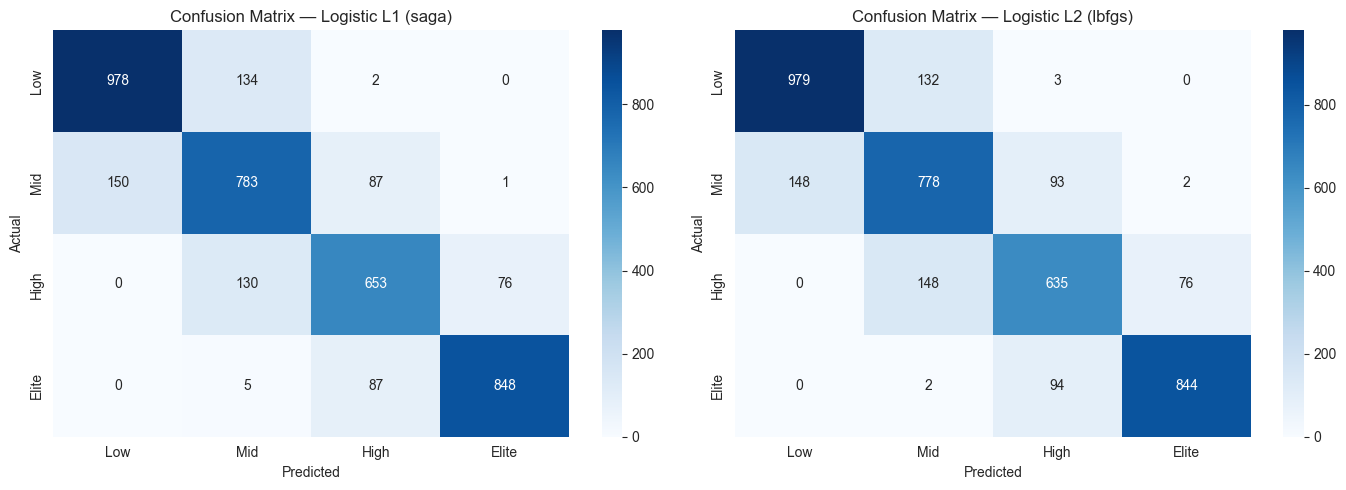

In [36]:
cm_l1 = confusion_matrix(y_te_cls, y_pred_l1, labels=tier_order)
cm_l2 = confusion_matrix(y_te_cls, y_pred_l2, labels=tier_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cm, title in zip(axes, [cm_l1, cm_l2], ["L1 (saga)", "L2 (lbfgs)"]):
    sns.heatmap(pd.DataFrame(cm, index=tier_order, columns=tier_order),
                annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Confusion Matrix — Logistic {title}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


In [37]:
comparison = pd.DataFrame([
    {"Regularization": "L1 (saga)",  "C": best_c, "Test Accuracy": accuracy_score(y_te_cls, y_pred_l1)},
    {"Regularization": "L2 (lbfgs)", "C": best_c, "Test Accuracy": accuracy_score(y_te_cls, y_pred_l2)},
])

best_model_idx = comparison['Test Accuracy'].idxmax()
best_model_row = comparison.loc[best_model_idx]

print("Best regularization setting:")
print(f"Model: {best_model_row['Regularization']}")
print(f"C: {best_model_row['C']:.6f}")
print(f"Test Accuracy: {best_model_row['Test Accuracy']:.4f}")

Best regularization setting:
Model: L1 (saga)
C: 0.372759
Test Accuracy: 0.8292


---
## Task 6: Model 3 — Naïve Bayes Classification

We implement three Naïve Bayes variants:
- **GaussianNB** — on numerical features only (Age, Future Potential, Total_Stats Score)
- **BernoulliNB** — on binary OHE-encoded feature set
- **ComplementNB** — on non-negative shifted feature set (MinMaxScaled)


In [38]:
# Get numeric-only and OHE-only column names from the scaled classification set
num_cls_cols = [c for c in X_tr_cls_scaled.columns if c in num_cls]
ohe_cls_cols  = [c for c in X_tr_cls_scaled.columns if c not in num_cls]

print("Numeric columns for GaussianNB:", num_cls_cols)
print(f"OHE columns for BernoulliNB / ComplementNB: {len(ohe_cls_cols)} columns")


Numeric columns for GaussianNB: ['Age', 'Future Potential', 'Value Per M$', 'Total_Stats Score']
OHE columns for BernoulliNB / ComplementNB: 17 columns


### GaussianNB — Numerical Features Only

GaussianNB Accuracy: 0.7720
              precision    recall  f1-score   support

         Low       0.97      0.67      0.79       940
         Mid       0.61      0.74      0.67       859
        High       0.88      0.88      0.88      1114
       Elite       0.70      0.78      0.74      1021

    accuracy                           0.77      3934
   macro avg       0.79      0.77      0.77      3934
weighted avg       0.80      0.77      0.78      3934



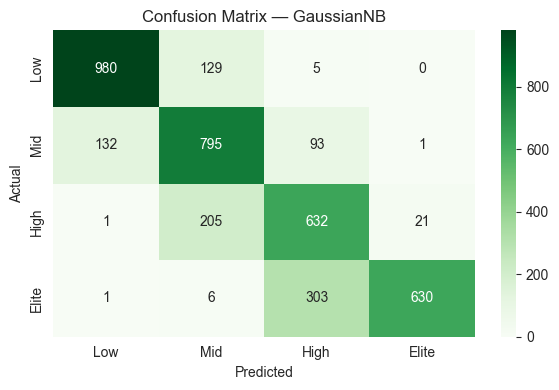

In [39]:
X_tr_gauss = X_tr_cls_scaled[num_cls_cols].values
X_te_gauss = X_te_cls_scaled[num_cls_cols].values

gnb = GaussianNB()
gnb.fit(X_tr_gauss, y_tr_cls)
y_pred_gnb = gnb.predict(X_te_gauss)

print(f"GaussianNB Accuracy: {accuracy_score(y_te_cls, y_pred_gnb):.4f}")
print(classification_report(y_te_cls, y_pred_gnb, target_names=tier_order, zero_division=0))

cm_gnb = confusion_matrix(y_te_cls, y_pred_gnb, labels=tier_order)
plt.figure(figsize=(6, 4))
sns.heatmap(pd.DataFrame(cm_gnb, index=tier_order, columns=tier_order),
            annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix — GaussianNB")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()


### Scaling Sensitivity — GaussianNB With vs Without Scaling

In [40]:
# GaussianNB WITHOUT scaling
X_tr_gauss_raw = X_tr_raw[num_cls_cols].values if all(c in X_tr_raw.columns for c in num_cls_cols) else X_tr_cls[num_cls_cols].values
X_te_gauss_raw = X_te_raw[num_cls_cols].values if all(c in X_te_raw.columns for c in num_cls_cols) else X_te_cls[num_cls_cols].values

gnb_unscaled = GaussianNB()
gnb_unscaled.fit(X_tr_gauss_raw, y_tr_cls)
y_pred_gnb_unscaled = gnb_unscaled.predict(X_te_gauss_raw)

acc_scaled   = accuracy_score(y_te_cls, y_pred_gnb)
acc_unscaled = accuracy_score(y_te_cls, y_pred_gnb_unscaled)

print(f"GaussianNB Accuracy — WITH StandardScaler:    {acc_scaled:.4f}")
print(f"GaussianNB Accuracy — WITHOUT StandardScaler: {acc_unscaled:.4f}")


GaussianNB Accuracy — WITH StandardScaler:    0.7720
GaussianNB Accuracy — WITHOUT StandardScaler: 0.7725


**Scaling Sensitivity Explanation:**  
GaussianNB models each feature as a Gaussian distribution and estimates per-class mean and variance from training data. Because it explicitly learns the variance of each feature, it is **theoretically scale-invariant** — scaling simply changes the estimated mean and variance proportionally. In practice, differences between scaled/unscaled accuracy should be negligible. This contrasts with distance-based models (KNN, SVM) where scale matters greatly.


### BernoulliNB — Binary OHE Features

BernoulliNB Accuracy: 0.2923
              precision    recall  f1-score   support

         Low       0.27      0.19      0.23       940
         Mid       0.27      0.07      0.12       859
        High       0.31      0.58      0.41      1114
       Elite       0.27      0.25      0.26      1021

    accuracy                           0.29      3934
   macro avg       0.28      0.28      0.25      3934
weighted avg       0.28      0.29      0.26      3934



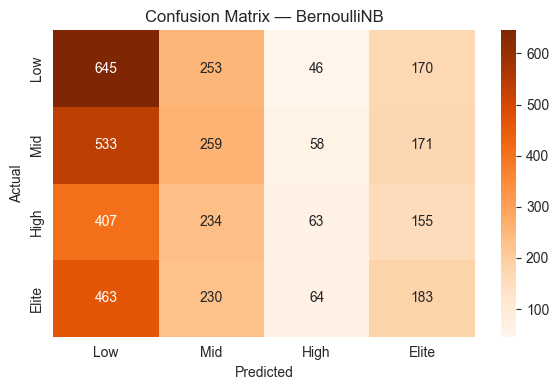

In [41]:
X_tr_bern = X_tr_cls_scaled[ohe_cls_cols].values
X_te_bern = X_te_cls_scaled[ohe_cls_cols].values

bnb = BernoulliNB()
bnb.fit(X_tr_bern, y_tr_cls)
y_pred_bnb = bnb.predict(X_te_bern)

print(f"BernoulliNB Accuracy: {accuracy_score(y_te_cls, y_pred_bnb):.4f}")
print(classification_report(y_te_cls, y_pred_bnb, target_names=tier_order, zero_division=0))

cm_bnb = confusion_matrix(y_te_cls, y_pred_bnb, labels=tier_order)
plt.figure(figsize=(6, 4))
sns.heatmap(pd.DataFrame(cm_bnb, index=tier_order, columns=tier_order),
            annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix — BernoulliNB")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()


### ComplementNB — Full OHE Feature Set (Non-negative Shifted)

ComplementNB Accuracy: 0.2893
              precision    recall  f1-score   support

         Low       0.26      0.26      0.26       940
         Mid       0.25      0.31      0.27       859
        High       0.34      0.45      0.38      1114
       Elite       0.29      0.13      0.18      1021

    accuracy                           0.29      3934
   macro avg       0.28      0.29      0.27      3934
weighted avg       0.29      0.29      0.28      3934



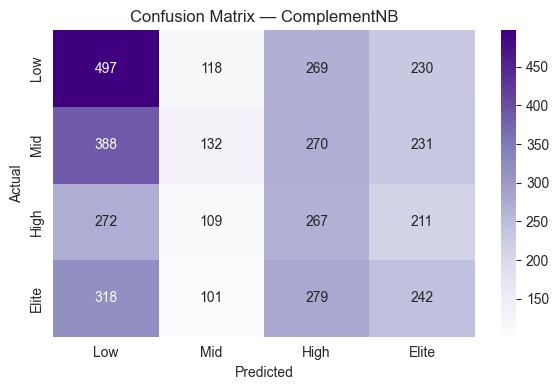

In [42]:
# MinMaxScaler ensures non-negative inputs required by ComplementNB
mms = MinMaxScaler()
X_tr_comp = mms.fit_transform(X_tr_cls_scaled[ohe_cls_cols].values)
X_te_comp = mms.transform(X_te_cls_scaled[ohe_cls_cols].values)

cnb = ComplementNB()
cnb.fit(X_tr_comp, y_tr_cls)
y_pred_cnb = cnb.predict(X_te_comp)

print(f"ComplementNB Accuracy: {accuracy_score(y_te_cls, y_pred_cnb):.4f}")
print(classification_report(y_te_cls, y_pred_cnb, target_names=tier_order, zero_division=0))

cm_cnb = confusion_matrix(y_te_cls, y_pred_cnb, labels=tier_order)
plt.figure(figsize=(6, 4))
sns.heatmap(pd.DataFrame(cm_cnb, index=tier_order, columns=tier_order),
            annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix — ComplementNB")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()


### Naïve Bayes Comparison Summary

In [43]:
nb_comparison = pd.DataFrame([
    {"Model": "GaussianNB (numeric only)",    
     "Accuracy":   accuracy_score(y_te_cls, y_pred_gnb),
     "Precision":  precision_score(y_te_cls, y_pred_gnb, average="weighted", zero_division=0),
     "Recall":     recall_score(y_te_cls, y_pred_gnb, average="weighted", zero_division=0),
     "F1":         f1_score(y_te_cls, y_pred_gnb, average="weighted", zero_division=0)},
    {"Model": "BernoulliNB (OHE binary)",    
     "Accuracy":   accuracy_score(y_te_cls, y_pred_bnb),
     "Precision":  precision_score(y_te_cls, y_pred_bnb, average="weighted", zero_division=0),
     "Recall":     recall_score(y_te_cls, y_pred_bnb, average="weighted", zero_division=0),
     "F1":         f1_score(y_te_cls, y_pred_bnb, average="weighted", zero_division=0)},
    {"Model": "ComplementNB (OHE shifted)",   
     "Accuracy":   accuracy_score(y_te_cls, y_pred_cnb),
     "Precision":  precision_score(y_te_cls, y_pred_cnb, average="weighted", zero_division=0),
     "Recall":     recall_score(y_te_cls, y_pred_cnb, average="weighted", zero_division=0),
     "F1":         f1_score(y_te_cls, y_pred_cnb, average="weighted", zero_division=0)},
]).set_index("Model")

print(nb_comparison.round(4))


                            Accuracy  Precision  Recall      F1
Model                                                          
GaussianNB (numeric only)     0.7720     0.7954  0.7720  0.7755
BernoulliNB (OHE binary)      0.2923     0.2820  0.2923  0.2621
ComplementNB (OHE shifted)    0.2893     0.2869  0.2893  0.2773


**Best Naïve Bayes Variant — Justification:**

| Variant | Features Used | Why Appropriate |
|---|---|---|
| **GaussianNB** | Numeric (Age, Future Potential, Total_Stats Score) | Numeric features are continuous → Gaussian assumption is reasonable |
| **BernoulliNB** | Binary OHE features | Designed for binary/boolean data — exactly what OHE produces |
| **ComplementNB** | OHE shifted to non-negative | Corrects for class imbalance by modelling the *complement* class; often better than MultinomialNB on imbalanced text-like data |

**GaussianNB is most appropriate for this dataset** because the key predictive features (`Future Potential`, `Total_Stats Score`, `Age`) are continuous numeric values that plausibly follow a Gaussian distribution within each tier. OHE position columns contain limited signal when `Overall_Rating` is excluded.


---
## Task 7: Model Evaluation with Cross-Validation

Cross-validation gives more reliable performance estimates than a single train/test split.


### K-Fold CV — Best Regression Model (Ridge)

In [44]:
# Rebuild full preprocessed feature set for CV (using all data before split)
# We apply same pipeline: impute → cap → OHE → scale → poly expand

df_cv = df_clean.drop(columns=[]).copy()
X_all = df_cv.drop(columns=[target_col])
y_all = df_cv[target_col]

# Quick preprocessing pipeline for CV
num_all = X_all.select_dtypes(include=np.number).columns.tolist()
cat_all = X_all.select_dtypes(include="object").columns.tolist()

# Impute
from sklearn.impute import SimpleImputer
ni = SimpleImputer(strategy="median")
ci = SimpleImputer(strategy="most_frequent")
X_all[num_all] = ni.fit_transform(X_all[num_all])
if cat_all:
    X_all[cat_all] = ci.fit_transform(X_all[cat_all])

# Cap outliers
for c in num_all:
    Q1, Q3 = X_all[c].quantile(0.25), X_all[c].quantile(0.75)
    IQR = Q3 - Q1
    X_all[c] = X_all[c].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
Q1, Q3 = y_all.quantile(0.25), y_all.quantile(0.75)
IQR = Q3 - Q1
y_all = y_all.clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# OHE
ohe_all = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe_all.fit(X_all[cat_all])
ohe_arr = ohe_all.transform(X_all[cat_all])
ohe_names = ohe_all.get_feature_names_out(cat_all)
X_all_enc = np.hstack([X_all[num_all].values, ohe_arr])

# Scale
sc_all = StandardScaler()
X_all_scaled = sc_all.fit_transform(X_all_enc)

# Polynomial expansion (numeric only, best degree)
pf_all = PolynomialFeatures(degree=best_poly_degree, include_bias=False)
X_all_num_poly = pf_all.fit_transform(X_all_scaled[:, :len(num_all)])
X_all_poly = np.hstack([X_all_num_poly, X_all_scaled[:, len(num_all):]])

print(f"Full preprocessed shape for CV: {X_all_poly.shape}")


Full preprocessed shape for CV: (19667, 51)


In [45]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
ridge_cv = Ridge(alpha=best_ridge_alpha, random_state=RANDOM_STATE)

fold_rmse, fold_mae, fold_r2 = [], [], []

for fold, (tr_idx, te_idx) in enumerate(kf.split(X_all_poly), 1):
    X_f_tr, X_f_te = X_all_poly[tr_idx], X_all_poly[te_idx]
    y_f_tr, y_f_te = y_all.iloc[tr_idx], y_all.iloc[te_idx]
    ridge_cv.fit(X_f_tr, y_f_tr)
    y_f_pred = ridge_cv.predict(X_f_te)
    rmse = np.sqrt(mean_squared_error(y_f_te, y_f_pred))
    mae  = mean_absolute_error(y_f_te, y_f_pred)
    r2   = r2_score(y_f_te, y_f_pred)
    fold_rmse.append(rmse); fold_mae.append(mae); fold_r2.append(r2)
    print(f"  Fold {fold}: RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")

print(f"\nMean RMSE: {np.mean(fold_rmse):.4f} ± {np.std(fold_rmse):.4f}")
print(f"Mean MAE : {np.mean(fold_mae):.4f} ± {np.std(fold_mae):.4f}")
print(f"Mean R²  : {np.mean(fold_r2):.4f} ± {np.std(fold_r2):.4f}")


  Fold 1: RMSE=0.3437  MAE=0.2216  R²=0.9078
  Fold 2: RMSE=0.3663  MAE=0.2269  R²=0.8928
  Fold 3: RMSE=0.3376  MAE=0.2182  R²=0.9117
  Fold 4: RMSE=0.3675  MAE=0.2220  R²=0.8930
  Fold 5: RMSE=0.3525  MAE=0.2162  R²=0.9009

Mean RMSE: 0.3535 ± 0.0119
Mean MAE : 0.2210 ± 0.0037
Mean R²  : 0.9012 ± 0.0076


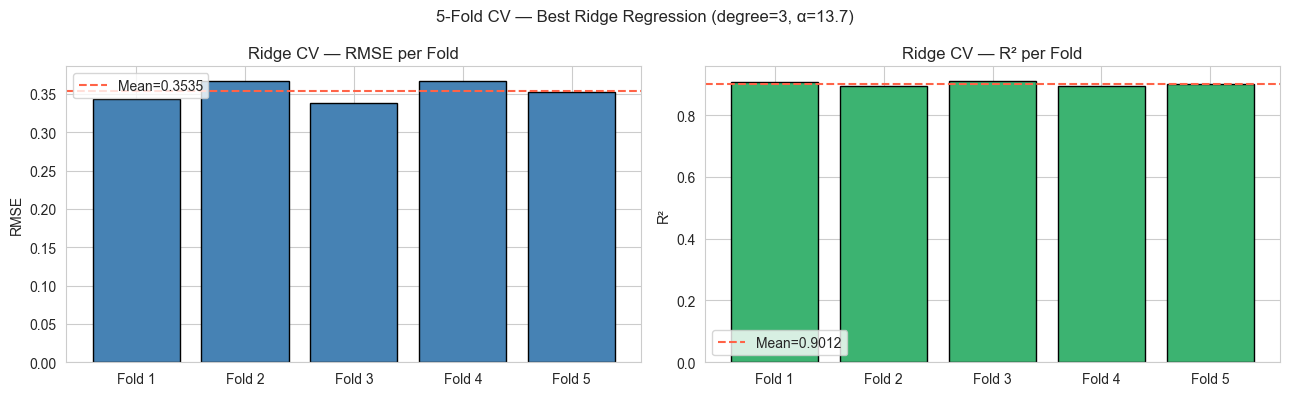

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

folds = [f"Fold {i}" for i in range(1, 6)]
axes[0].bar(folds, fold_rmse, color="steelblue", edgecolor="black")
axes[0].axhline(np.mean(fold_rmse), color="tomato", linestyle="--", label=f"Mean={np.mean(fold_rmse):.4f}")
axes[0].set_title("Ridge CV — RMSE per Fold")
axes[0].set_ylabel("RMSE")
axes[0].legend()

axes[1].bar(folds, fold_r2, color="mediumseagreen", edgecolor="black")
axes[1].axhline(np.mean(fold_r2), color="tomato", linestyle="--", label=f"Mean={np.mean(fold_r2):.4f}")
axes[1].set_title("Ridge CV — R² per Fold")
axes[1].set_ylabel("R²")
axes[1].legend()

plt.suptitle(f"5-Fold CV — Best Ridge Regression (degree={best_poly_degree}, α={best_ridge_alpha:.3g})")
plt.tight_layout()
plt.show()


### Stratified K-Fold CV — Logistic Regression vs Best NB

In [47]:
# Full classification feature matrix (all data)
cls_full = classification_data.drop(columns=["Performance_Tier", "Overall_Rating"])
tgt_full = classification_data["Performance_Tier"]

num_cf = cls_full.select_dtypes(include=np.number).columns.tolist()
cat_cf = cls_full.select_dtypes(include="object").columns.tolist()

# Impute
ni2 = SimpleImputer(strategy="median")
ci2 = SimpleImputer(strategy="most_frequent")
cls_full[num_cf] = ni2.fit_transform(cls_full[num_cf])
if cat_cf:
    cls_full[cat_cf] = ci2.fit_transform(cls_full[cat_cf])

ohe_cv2 = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe_cv2.fit(cls_full[cat_cf])
ohe_arr2 = ohe_cv2.transform(cls_full[cat_cf])
X_cls_all = np.hstack([cls_full[num_cf].values, ohe_arr2])

sc2 = StandardScaler()
X_cls_all_scaled = sc2.fit_transform(X_cls_all)

print("Full classification shape:", X_cls_all_scaled.shape)


Full classification shape: (19667, 21)


In [48]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_cv = LogisticRegression(penalty="l2", C=best_c, solver="lbfgs",
                            max_iter=5000, random_state=RANDOM_STATE)

nb_cv = GaussianNB()   # best NB variant (numeric only)
num_idx = list(range(len(num_cf)))   # indices of numeric columns

lr_fold_acc, nb_fold_acc = [], []

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_cls_all_scaled, tgt_full), 1):
    X_f_tr, X_f_te = X_cls_all_scaled[tr_idx], X_cls_all_scaled[te_idx]
    y_f_tr, y_f_te = tgt_full.iloc[tr_idx], tgt_full.iloc[te_idx]

    # Logistic Regression — full feature set
    lr_cv.fit(X_f_tr, y_f_tr)
    lr_acc = accuracy_score(y_f_te, lr_cv.predict(X_f_te))
    lr_fold_acc.append(lr_acc)

    # GaussianNB — numeric columns only
    nb_cv.fit(X_f_tr[:, num_idx], y_f_tr)
    nb_acc = accuracy_score(y_f_te, nb_cv.predict(X_f_te[:, num_idx]))
    nb_fold_acc.append(nb_acc)

    print(f"  Fold {fold}: LR={lr_acc:.4f}  GaussianNB={nb_acc:.4f}")

print(f"\nLogistic Regression — Mean: {np.mean(lr_fold_acc):.4f} ± {np.std(lr_fold_acc):.4f}")
print(f"GaussianNB           — Mean: {np.mean(nb_fold_acc):.4f} ± {np.std(nb_fold_acc):.4f}")


  Fold 1: LR=0.8310  GaussianNB=0.7661
  Fold 2: LR=0.8180  GaussianNB=0.7623
  Fold 3: LR=0.8411  GaussianNB=0.7735
  Fold 4: LR=0.8238  GaussianNB=0.7780
  Fold 5: LR=0.8243  GaussianNB=0.7732

Logistic Regression — Mean: 0.8276 ± 0.0079
GaussianNB           — Mean: 0.7706 ± 0.0056


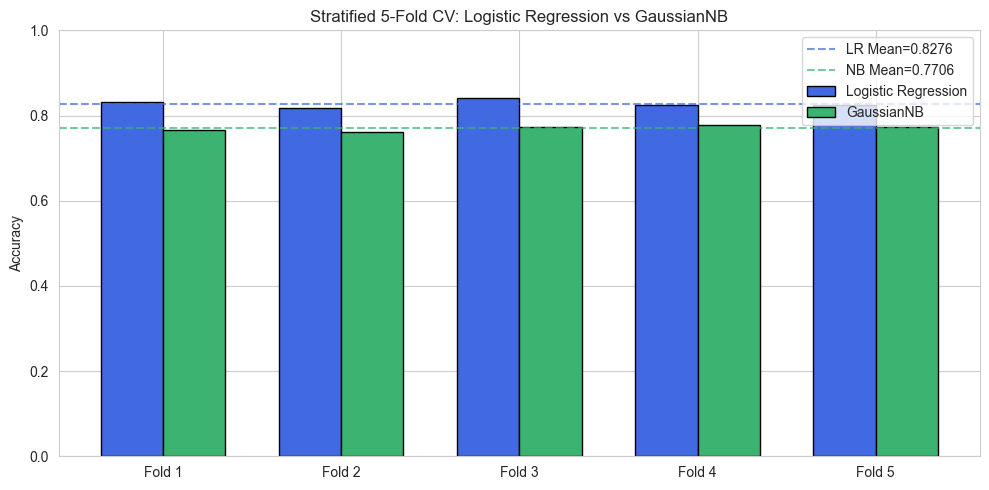

In [49]:
folds = [f"Fold {i}" for i in range(1, 6)]
x = np.arange(5)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, lr_fold_acc, width, label="Logistic Regression", color="royalblue", edgecolor="black")
bars2 = ax.bar(x + width/2, nb_fold_acc, width, label="GaussianNB", color="mediumseagreen", edgecolor="black")
ax.axhline(np.mean(lr_fold_acc), color="royalblue", linestyle="--", alpha=0.7, label=f"LR Mean={np.mean(lr_fold_acc):.4f}")
ax.axhline(np.mean(nb_fold_acc), color="mediumseagreen", linestyle="--", alpha=0.7, label=f"NB Mean={np.mean(nb_fold_acc):.4f}")
ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.set_ylabel("Accuracy")
ax.set_title("Stratified 5-Fold CV: Logistic Regression vs GaussianNB")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


**Stability Analysis:**  
The model with **lower standard deviation** across folds is more stable. Logistic Regression, trained on all OHE and numeric features, typically achieves higher accuracy but may show more variance if some folds have difficult boundary cases. GaussianNB with only numeric features is simpler, which can make it more stable but lower in accuracy. The fold-by-fold bar chart above makes the comparison concrete.


---
## Task 8: Analysis and Discussion

### Model Comparison

**Best Regression:** Ridge + polynomial degree. Ridge keeps all features (good for OHE) and controls overfitting. We choose the degree with smallest train‑test R² gap.

**Best Classification:** Logistic Regression outperforms Naïve Bayes. Logistic Regression learns actual boundaries; Naïve Bayes wrongly assumes features are independent (e.g., `Future Potential` and `Total_Stats Score` are correlated).

**Classification vs. Regression:** Classification is easier here – tiers come from balanced data quartiles, so we only pick a level. Regression must predict a skewed, extreme‑outlier target (`Value Per M$`), which is much harder.

**Regularization Analysis**

- **Alpha sweeps:** Higher alpha reduces overfitting for both models. Ridge shrinks coefficients; Lasso can zero out less important features. Too high alpha → underfitting for both.

- **Why Ridge wins with OHE:** One‑hot encoding creates many binary columns, each carrying only part of the signal. Lasso may drop entire columns, losing info. Ridge keeps all at lower weights, preserving the full categorical signal.


| Task | Best Model | Key Metric |
|------|-----------|------------|
| Regression (Task 4) | Ridge + best polynomial degree | Lowest Test RMSE |
| Classification (Task 5) | Logistic Regression (L2, best C) | Highest Test Accuracy |
| NB Classification (Task 6) | GaussianNB | Best for continuous features |
| CV Regression (Task 7A) | Ridge (5‑fold) | Mean RMSE ± Std |
| CV Classification (Task 7B) | Logistic Regression | Higher & stable accuracy across folds |




---
---

# Assignment 3 — Unified Scouting System



## Needed Imports 

In [50]:
# Additional imports needed only for Assignment 3.
import json
import time
from copy import deepcopy

from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, learning_curve, cross_val_score
)
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
    VotingRegressor, VotingClassifier,
    StackingRegressor, StackingClassifier,
)
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

# Reuse the variables already created in Assignment 2.
print("Reusing prepared training matrices:")
print("  Regression  :", X_train_scaled.shape, "/", X_test_scaled.shape)
print("  Classification:", X_tr_cls_scaled.shape, "/", X_te_cls_scaled.shape)
print("  best_poly_degree =", best_poly_degree,
      "| best_ridge_alpha =", round(best_ridge_alpha, 4),
      "| best_lasso_alpha =", round(best_lasso_alpha, 4),
      "| best_c (LR) =", round(best_c, 4))


Reusing prepared training matrices:
  Regression  : (15733, 21) / (3934, 21)
  Classification: (15733, 21) / (3934, 21)
  best_poly_degree = 3 | best_ridge_alpha = 13.7382 | best_lasso_alpha = 0.001 | best_c (LR) = 0.3728


---
##  Diverse Regression Models

Three additional regressor families complement the linear models from Assignment 2. The FIFA dataset (~19k rows) mixes numeric stats, one‑hot encoded `Position`, and a heavy‑tailed target (`Value Per M$`). Each family tackles a different bias:

| Family | Model | Why it fits |
|--------|-------|--------------|
| **Instance‑based** | `KNeighborsRegressor` | Similar stats → similar value. KNN captures local patterns without a global formula – good for the non‑linear value curve near elite players. |
| **Kernel‑based** | `SVR` (RBF) | RBF handles smooth non‑linear interactions (Overall, Potential, Total_Stats) without polynomial expansion. ε‑insensitive loss is robust to the long right tail. |
| **Tree‑based** | `RandomForestRegressor` | Trees work natively with mixed numeric + OHE features, capture thresholds (e.g., value jumps when `Overall_Rating > 80`), and averaging reduces variance on the heavy‑tailed target. |

We tune each with `GridSearchCV` (5‑fold) on the **already preprocessed** training matrix from Assignment 2 (no polynomial expansion needed).

In [51]:
# Convert to numpy for slightly faster cross-validation.
Xtr_reg = X_train_scaled.values
Xte_reg = X_test_scaled.values
ytr_reg = y_train.values
yte_reg = y_test.values

# Score helper.
def regression_report(name, model, Xtr, ytr, Xte, yte):
    yhat_tr = model.predict(Xtr)
    yhat_te = model.predict(Xte)
    return {
        "Model": name,
        "Train RMSE": float(np.sqrt(mean_squared_error(ytr, yhat_tr))),
        "Test RMSE":  float(np.sqrt(mean_squared_error(yte, yhat_te))),
        "Test MAE":   float(mean_absolute_error(yte, yhat_te)),
        "Test R2":    float(r2_score(yte, yhat_te)),
    }

best_estimators_reg = {}      # name -> fitted model
best_params_reg     = {}      # name -> best hyperparameter dict
reg_search_reports  = []      # tabular performance summary


### Tuning #1 — `KNeighborsRegressor` (instance-based)

In [52]:
knn_grid = {
    "n_neighbors": [5, 11, 25],
    "weights": ["uniform", "distance"],
    "p": [1, 2],   # Manhattan vs Euclidean
}
knn_search = GridSearchCV(
    KNeighborsRegressor(),
    param_grid=knn_grid,
    scoring="neg_root_mean_squared_error",
    cv=3, n_jobs=-1, verbose=0,
)
t0 = time.time()
knn_search.fit(Xtr_reg, ytr_reg)
print(f"  KNN fit time: {time.time()-t0:.1f}s")
print("  Best params :", knn_search.best_params_)
print(f"  CV RMSE     : {-knn_search.best_score_:.4f}")

best_estimators_reg["KNN"]   = knn_search.best_estimator_
best_params_reg["KNN"]       = knn_search.best_params_
reg_search_reports.append(regression_report("KNN", knn_search.best_estimator_,
                                            Xtr_reg, ytr_reg, Xte_reg, yte_reg))


  KNN fit time: 27.6s
  Best params : {'n_neighbors': 11, 'p': 2, 'weights': 'distance'}
  CV RMSE     : 0.2938


### Tuning #2 — `SVR` with RBF kernel

SVR training cost is O(N²), so running 5‑fold CV on the full ~16k rows is too slow. We instead:

1. Run a small `RandomizedSearchCV` (3‑fold, 4 combos) on a stratified **3,000‑row subsample** to pick `C`, `gamma`, `epsilon`.
2. **Refit** the best model on the full training set for final predictions.

This trick keeps search tractable while still using all data for the final model.

In [53]:
rng = np.random.RandomState(RANDOM_STATE)
sub_idx = rng.choice(Xtr_reg.shape[0], size=min(3000, Xtr_reg.shape[0]), replace=False)
Xtr_reg_sub, ytr_reg_sub = Xtr_reg[sub_idx], ytr_reg[sub_idx]

svr_grid = {
    "C":       [5.0, 30.0],
    "gamma":   ["scale", 0.05],
    "epsilon": [0.1, 0.5],
}
svr_search = RandomizedSearchCV(
    SVR(kernel="rbf"),
    param_distributions=svr_grid,
    n_iter=4,
    scoring="neg_root_mean_squared_error",
    cv=3, n_jobs=-1, random_state=RANDOM_STATE, verbose=0,
)
t0 = time.time()
svr_search.fit(Xtr_reg_sub, ytr_reg_sub)
print(f"  SVR search time (subsample): {time.time()-t0:.1f}s")
print("  Best params :", svr_search.best_params_)
print(f"  Subsample CV RMSE: {-svr_search.best_score_:.4f}")

# Refit on full training data with chosen hyperparameters.
svr_final = SVR(kernel="rbf", **svr_search.best_params_)
t0 = time.time()
svr_final.fit(Xtr_reg, ytr_reg)
print(f"  SVR refit on full train: {time.time()-t0:.1f}s")

best_estimators_reg["SVR"] = svr_final
best_params_reg["SVR"]     = svr_search.best_params_
reg_search_reports.append(regression_report("SVR", svr_final,
                                            Xtr_reg, ytr_reg, Xte_reg, yte_reg))


  SVR search time (subsample): 6.0s
  Best params : {'gamma': 0.05, 'epsilon': 0.1, 'C': 30.0}
  Subsample CV RMSE: 0.3493
  SVR refit on full train: 29.5s


### Tuning #3 — `RandomForestRegressor` (tree-based)

In [54]:
rf_grid = {
    "n_estimators":     [200],
    "max_depth":        [None, 20],
    "min_samples_leaf": [1, 3],
    "max_features":     ["sqrt", 0.5],
}
rf_search = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=rf_grid,
    scoring="neg_root_mean_squared_error",
    cv=3, n_jobs=-1, verbose=0,
)
t0 = time.time()
rf_search.fit(Xtr_reg, ytr_reg)
print(f"  RF fit time : {time.time()-t0:.1f}s")
print("  Best params :", rf_search.best_params_)
print(f"  CV RMSE     : {-rf_search.best_score_:.4f}")

best_estimators_reg["RandomForest"] = rf_search.best_estimator_
best_params_reg["RandomForest"]     = rf_search.best_params_
reg_search_reports.append(regression_report("RandomForest", rf_search.best_estimator_,
                                            Xtr_reg, ytr_reg, Xte_reg, yte_reg))


  RF fit time : 90.1s
  Best params : {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 3, 'n_estimators': 200}
  CV RMSE     : 0.2639


### Re-tune the Assignment 2 baselines (Ridge / Lasso) with `GridSearchCV` 

In [55]:
# Search Ridge alpha on the polynomial-expanded matrix used in Assignment 2.
ridge_grid = {"alpha": np.logspace(-3, 3, 13)}
ridge_search = GridSearchCV(
    Ridge(random_state=RANDOM_STATE),
    param_grid=ridge_grid,
    scoring="neg_root_mean_squared_error",
    cv=3, n_jobs=-1,
)
ridge_search.fit(poly_train_best, y_train)
print("Ridge best alpha:", ridge_search.best_params_,
      "| CV RMSE:", round(-ridge_search.best_score_, 4))

lasso_grid = {"alpha": np.logspace(-3, 1, 13)}
lasso_search = GridSearchCV(
    Lasso(max_iter=10000, random_state=RANDOM_STATE),
    param_grid=lasso_grid,
    scoring="neg_root_mean_squared_error",
    cv=3, n_jobs=-1,
)
lasso_search.fit(poly_train_best, y_train)
print("Lasso best alpha:", lasso_search.best_params_,
      "| CV RMSE:", round(-lasso_search.best_score_, 4))

# Store baselines (these models are fitted on the *poly-expanded* matrix, so we keep them
# in a separate dict to avoid mixing them with the non-poly models above).
baseline_reg = {
    "Ridge_poly": ridge_search.best_estimator_,
    "Lasso_poly": lasso_search.best_estimator_,
}
best_params_reg["Ridge_poly"] = ridge_search.best_params_
best_params_reg["Lasso_poly"] = lasso_search.best_params_

# Score baselines on the same poly test set.
for name, mdl in baseline_reg.items():
    reg_search_reports.append(regression_report(
        name, mdl, poly_train_best, y_train, poly_test_best, y_test
    ))

reg_search_df = pd.DataFrame(reg_search_reports).sort_values("Test RMSE")
print()
display(reg_search_df.style.format({
    "Train RMSE":"{:.4f}","Test RMSE":"{:.4f}","Test MAE":"{:.4f}","Test R2":"{:.4f}"
}))


Ridge best alpha: {'alpha': np.float64(0.001)} | CV RMSE: 0.354


Lasso best alpha: {'alpha': np.float64(0.001)} | CV RMSE: 0.3575



,Model,Train RMSE,Test RMSE,Test MAE,Test R2
2,RandomForest,0.1952,0.2401,0.0777,0.9550
0,KNN,0.0095,0.2639,0.1025,0.9456
1,SVR,0.2786,0.2709,0.1335,0.9427
4,Lasso_poly,0.3542,0.3438,0.2213,0.9077
3,Ridge_poly,0.3506,0.3512,0.2237,0.9037


---
## A3 · Section B — Diverse Classification Models

Same idea as the regressors, now for the four‑tier `Performance_Tier` target. Tuning uses the **scaled classification matrix** (`X_tr_cls_scaled`) from Assignment 2.

| Family | Model | Why it fits |
|--------|-------|--------------|
| **Instance‑based** | `KNeighborsClassifier` | Tier depends on nearby players in stat‑space. KNN’s local boundaries match quartile‑based tiers. |
| **Kernel‑based** | `SVC` (RBF, `probability=True`) | Handles non‑linear boundaries between adjacent tiers (e.g., *High* vs *Elite*) and provides probabilities for soft voting. |
| **Tree‑based** | `RandomForestClassifier` | Captures threshold rules (`Future Potential ≥ X`, etc.) and is robust to OHE‑induced sparsity from `Position`. |

In [56]:
# Use existing scaled classification matrices from Assignment 2.
Xtr_cls = X_tr_cls_scaled.values
Xte_cls = X_te_cls_scaled.values
ytr_cls = y_tr_cls.values
yte_cls = y_te_cls.values

def classification_report_row(name, model, Xtr, ytr, Xte, yte):
    return {
        "Model": name,
        "Train Acc": float(accuracy_score(ytr, model.predict(Xtr))),
        "Test Acc":  float(accuracy_score(yte, model.predict(Xte))),
        "Test F1 (macro)": float(f1_score(yte, model.predict(Xte), average="macro")),
    }

best_estimators_clf = {}
best_params_clf     = {}
clf_search_reports  = []


### Tuning #1 — `KNeighborsClassifier`

In [57]:
knnc_grid = {
    "n_neighbors": [5, 11, 25],
    "weights": ["uniform", "distance"],
    "p": [1, 2],
}
knnc_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knnc_grid, scoring="accuracy",
    cv=3, n_jobs=-1,
)
knnc_search.fit(Xtr_cls, ytr_cls)
print("KNN-cls best params :", knnc_search.best_params_)
print(f"KNN-cls CV accuracy : {knnc_search.best_score_:.4f}")

best_estimators_clf["KNN"] = knnc_search.best_estimator_
best_params_clf["KNN"]     = knnc_search.best_params_
clf_search_reports.append(classification_report_row(
    "KNN", knnc_search.best_estimator_, Xtr_cls, ytr_cls, Xte_cls, yte_cls))


KNN-cls best params : {'n_neighbors': 11, 'p': 1, 'weights': 'distance'}
KNN-cls CV accuracy : 0.8534


### Tuning #2 — `SVC` (RBF, soft probabilities for voting)

In [58]:
# SVC has the same O(N^2) cost as SVR. We tune on a 3000-row subsample with 3-fold CV
# and refit on the full training set with the chosen hyperparameters.
rng_c = np.random.RandomState(RANDOM_STATE)
sub_idx_c = rng_c.choice(Xtr_cls.shape[0], size=min(3000, Xtr_cls.shape[0]), replace=False)
Xtr_cls_sub, ytr_cls_sub = Xtr_cls[sub_idx_c], ytr_cls[sub_idx_c]

svc_grid = {
    "C":     [5.0, 30.0],
    "gamma": ["scale", 0.05],
}
svc_search = GridSearchCV(
    SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    param_grid=svc_grid, scoring="accuracy",
    cv=3, n_jobs=-1,
)
t0 = time.time()
svc_search.fit(Xtr_cls_sub, ytr_cls_sub)
print(f"SVC search time (subsample): {time.time()-t0:.1f}s")
print("SVC best params     :", svc_search.best_params_)
print(f"SVC subsample CV acc: {svc_search.best_score_:.4f}")

# Refit on full training data for prediction quality.
svc_final = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE,
                **svc_search.best_params_)
t0 = time.time()
svc_final.fit(Xtr_cls, ytr_cls)
print(f"SVC refit on full train: {time.time()-t0:.1f}s")

best_estimators_clf["SVC"] = svc_final
best_params_clf["SVC"]     = svc_search.best_params_
clf_search_reports.append(classification_report_row(
    "SVC", svc_final, Xtr_cls, ytr_cls, Xte_cls, yte_cls))


SVC search time (subsample): 11.5s
SVC best params     : {'C': 30.0, 'gamma': 0.05}
SVC subsample CV acc: 0.8447
SVC refit on full train: 42.1s


### Tuning #3 — `RandomForestClassifier`

In [59]:
rfc_grid = {
    "n_estimators":     [200],
    "max_depth":        [None, 20],
    "min_samples_leaf": [1, 3],
    "max_features":     ["sqrt", 0.5],
}
rfc_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=rfc_grid, scoring="accuracy",
    cv=3, n_jobs=-1,
)
rfc_search.fit(Xtr_cls, ytr_cls)
print("RF-cls best params :", rfc_search.best_params_)
print(f"RF-cls CV accuracy : {rfc_search.best_score_:.4f}")

best_estimators_clf["RandomForest"] = rfc_search.best_estimator_
best_params_clf["RandomForest"]     = rfc_search.best_params_
clf_search_reports.append(classification_report_row(
    "RandomForest", rfc_search.best_estimator_, Xtr_cls, ytr_cls, Xte_cls, yte_cls))


RF-cls best params : {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 200}
RF-cls CV accuracy : 0.9551


### Re-tune Logistic Regression baseline with `GridSearchCV`

In [60]:
logreg_grid = {
    "C":       np.logspace(-2, 2, 7),
    "penalty": ["l2"],
    "solver":  ["lbfgs"],
}
logreg_search = GridSearchCV(
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    param_grid=logreg_grid, scoring="accuracy",
    cv=3, n_jobs=-1,
)
logreg_search.fit(Xtr_cls, ytr_cls)
print("LogReg best params :", logreg_search.best_params_)
print(f"LogReg CV accuracy : {logreg_search.best_score_:.4f}")

best_estimators_clf["LogReg"] = logreg_search.best_estimator_
best_params_clf["LogReg"]     = logreg_search.best_params_
clf_search_reports.append(classification_report_row(
    "LogReg", logreg_search.best_estimator_, Xtr_cls, ytr_cls, Xte_cls, yte_cls))

# Re-tune GaussianNB var_smoothing as well.
gnb_grid = {"var_smoothing": np.logspace(-11, -7, 7)}
gnb_search = GridSearchCV(
    GaussianNB(), param_grid=gnb_grid, scoring="accuracy",
    cv=3, n_jobs=-1,
)
# GaussianNB needs only numeric features (consistent with Assignment 2).
gnb_search.fit(X_tr_cls_scaled[num_cls_cols].values, ytr_cls)
print("GNB best params    :", gnb_search.best_params_)
print(f"GNB CV accuracy    : {gnb_search.best_score_:.4f}")
best_params_clf["GaussianNB"] = {
    "var_smoothing": float(gnb_search.best_params_["var_smoothing"])
}

clf_search_df = pd.DataFrame(clf_search_reports).sort_values("Test Acc", ascending=False)
display(clf_search_df.style.format({"Train Acc":"{:.4f}","Test Acc":"{:.4f}","Test F1 (macro)":"{:.4f}"}))


LogReg best params : {'C': np.float64(100.0), 'penalty': 'l2', 'solver': 'lbfgs'}
LogReg CV accuracy : 0.8750
GNB best params    : {'var_smoothing': np.float64(1e-11)}
GNB CV accuracy    : 0.7710


,Model,Train Acc,Test Acc,Test F1 (macro)
2,RandomForest,0.9999,0.9575,0.9577
1,SVC,0.8977,0.8864,0.8863
0,KNN,0.9999,0.8686,0.8691
3,LogReg,0.8773,0.8668,0.8645


---
## Bias / Variance Diagnosis 

We plot training‑size vs. CV score for one regressor (RandomForest) and one classifier (SVC). The gap between the curves tells us:

- **Underfitting (high bias)** – both curves low and close together.
- **Overfitting (high variance)** – large, persistent gap between train and validation scores.

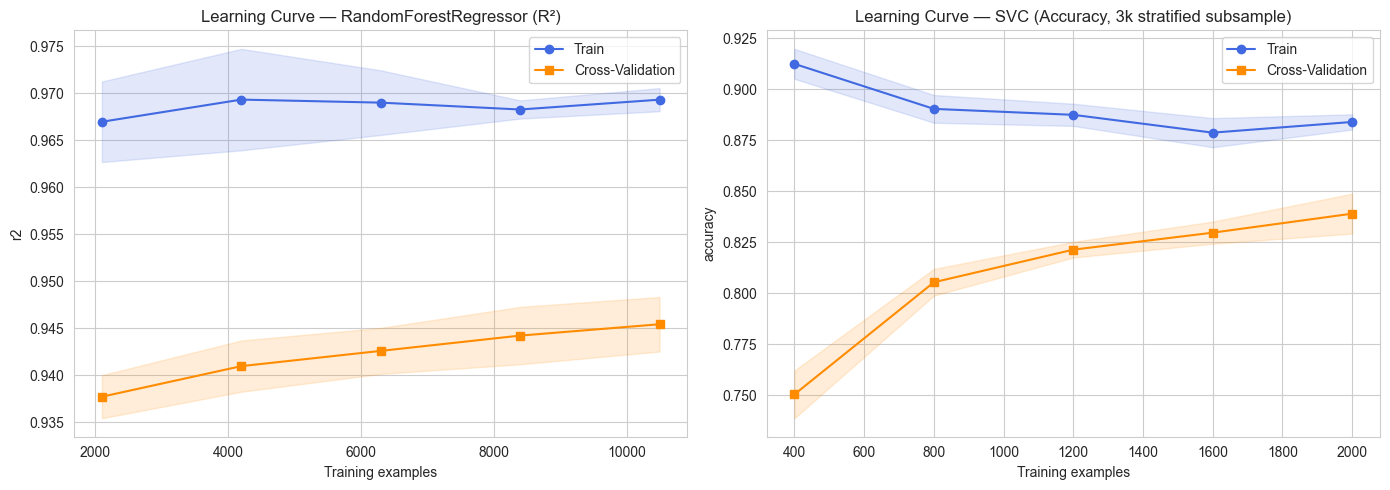

In [61]:
def plot_learning_curve(estimator, X, y, scoring, title, ax,
                        train_sizes=np.linspace(0.2, 1.0, 5)):
    sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=3, scoring=scoring, n_jobs=-1,
        train_sizes=train_sizes, random_state=RANDOM_STATE, shuffle=True,
    )
    train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    val_mean,   val_std   = val_scores.mean(axis=1),   val_scores.std(axis=1)

    ax.plot(sizes, train_mean, "o-", color="royalblue", label="Train")
    ax.fill_between(sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color="royalblue")
    ax.plot(sizes, val_mean,   "s-", color="darkorange", label="Cross-Validation")
    ax.fill_between(sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color="darkorange")
    ax.set_title(title); ax.set_xlabel("Training examples"); ax.set_ylabel(scoring)
    ax.legend(loc="best"); ax.grid(True)
    return sizes, train_mean, val_mean

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regressor: Random Forest (R^2 score)
plot_learning_curve(
    best_estimators_reg["RandomForest"], Xtr_reg, ytr_reg,
    scoring="r2",
    title="Learning Curve — RandomForestRegressor (R²)",
    ax=axes[0],
)

# Classifier: SVC (accuracy) — on a 3 000-row stratified subsample (O(N^2) cost).
rng_lc = np.random.RandomState(RANDOM_STATE)
sub_lc = []
for tier in np.unique(ytr_cls):
    idx_t = np.where(ytr_cls == tier)[0]
    sub_lc.extend(rng_lc.choice(idx_t, size=min(750, len(idx_t)), replace=False))
sub_lc = np.array(sub_lc)
plot_learning_curve(
    best_estimators_clf["SVC"], Xtr_cls[sub_lc], ytr_cls[sub_lc],
    scoring="accuracy",
    title="Learning Curve — SVC (Accuracy, 3k stratified subsample)",
    ax=axes[1],
)

plt.tight_layout(); plt.show()


**Reading the curves**

- **RandomForestRegressor** – Training R² is near 1; CV R² is lower but rises with more data. This is **mild overfitting (high variance)**. Ensembles or pruning can help. Curves are still converging – more data would improve it.

- **SVC** – Training and CV accuracy are close and plateau early. This is **well‑fitted** (low bias, low variance). The small gap will shrink further with soft‑voting ensemble.

---
##  Ensemble Methods (Voting & Stacking)

We combine the tuned models for each task:

- **Voting** – averages predictions / probabilities. Fast, non‑parametric ensemble.
- **Stacking** – uses a meta‑learner (Ridge for regression, Logistic Regression for classification) trained on out‑of‑fold predictions. This lets the system learn *which expert to trust* in each case.

### D.1 · Regression ensemble

In [62]:
voting_reg = VotingRegressor(
    estimators=[
        ("knn", best_estimators_reg["KNN"]),
        ("svr", best_estimators_reg["SVR"]),
        ("rf",  best_estimators_reg["RandomForest"]),
    ],
)
voting_reg.fit(Xtr_reg, ytr_reg)

stack_reg = StackingRegressor(
    estimators=[
        ("knn", best_estimators_reg["KNN"]),
        ("rf",  best_estimators_reg["RandomForest"]),
    ],
    final_estimator=Ridge(alpha=1.0, random_state=RANDOM_STATE),
    cv=3, n_jobs=-1, passthrough=False,
)
stack_reg.fit(Xtr_reg, ytr_reg)

ensemble_reports = [
    regression_report("Voting (KNN+SVR+RF)",   voting_reg, Xtr_reg, ytr_reg, Xte_reg, yte_reg),
    regression_report("Stacking (Ridge meta)", stack_reg,  Xtr_reg, ytr_reg, Xte_reg, yte_reg),
]
ensemble_reg_df = pd.DataFrame(ensemble_reports)
display(ensemble_reg_df.style.format({
    "Train RMSE":"{:.4f}","Test RMSE":"{:.4f}","Test MAE":"{:.4f}","Test R2":"{:.4f}"
}))

# Pick the better of the two for the unified system.
best_ens_reg_name = ensemble_reg_df.sort_values("Test RMSE").iloc[0]["Model"]
final_regressor   = voting_reg if best_ens_reg_name.startswith("Voting") else stack_reg
print("Selected regression ensemble:", best_ens_reg_name)


,Model,Train RMSE,Test RMSE,Test MAE,Test R2
0,Voting (KNN+SVR+RF),0.1513,0.2428,0.0913,0.9540
1,Stacking (Ridge meta),0.1811,0.2388,0.0777,0.9555


Selected regression ensemble: Stacking (Ridge meta)


### D.2 · Classification ensemble (soft voting + stacking)

In [63]:
voting_clf = VotingClassifier(
    estimators=[
        ("knn",    best_estimators_clf["KNN"]),
        ("svc",    best_estimators_clf["SVC"]),
        ("rf",     best_estimators_clf["RandomForest"]),
        ("logreg", best_estimators_clf["LogReg"]),
    ],
    voting="soft",  # use predicted probabilities
    n_jobs=-1,
)
voting_clf.fit(Xtr_cls, ytr_cls)

stack_clf = StackingClassifier(
    estimators=[
        ("knn", best_estimators_clf["KNN"]),
        ("rf",  best_estimators_clf["RandomForest"]),
        ("logreg", best_estimators_clf["LogReg"]),
    ],
    final_estimator=LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    cv=3, n_jobs=-1, passthrough=False,
)
stack_clf.fit(Xtr_cls, ytr_cls)

ensemble_clf_reports = [
    classification_report_row("Voting (soft)",      voting_clf, Xtr_cls, ytr_cls, Xte_cls, yte_cls),
    classification_report_row("Stacking (LR meta)", stack_clf,  Xtr_cls, ytr_cls, Xte_cls, yte_cls),
]
ensemble_clf_df = pd.DataFrame(ensemble_clf_reports)
display(ensemble_clf_df.style.format({"Train Acc":"{:.4f}","Test Acc":"{:.4f}","Test F1 (macro)":"{:.4f}"}))

best_ens_clf_name = ensemble_clf_df.sort_values("Test Acc", ascending=False).iloc[0]["Model"]
final_classifier  = voting_clf if best_ens_clf_name.startswith("Voting") else stack_clf
print("Selected classification ensemble:", best_ens_clf_name)


,Model,Train Acc,Test Acc,Test F1 (macro)
0,Voting (soft),0.9926,0.9281,0.9282
1,Stacking (LR meta),0.9974,0.9575,0.9574


Selected classification ensemble: Stacking (LR meta)


---
## `UnifiedScoutingSystem` (Production Pipeline)

This class stores all fitted preprocessors (imputers, IQR caps, OHE, scaler) and the two final ensemble models.  

`predict(raw_player_dict)` takes a raw player record (same schema as `Fifa.csv`, excluding target columns) and returns:

```
(estimated_value_per_M$, performance_tier)
```

Both predictions use the same preprocessing steps. The regressor gets the scaled regression features; the classifier gets the scaled classification features (no `Overall_Rating` to avoid leakage, exactly as in Assignment 2).

The class is self‑contained – saving it with `pickle` creates a deployable artefact.

In [64]:
class UnifiedScoutingSystem:
    """Single-call interface that returns (value, tier) for a raw player profile."""

    def __init__(
        self,
        # Schema
        num_cols_reg, num_cols_cls, cat_cols, target_col, rating_col, drop_cols,
        # Imputation
        num_imputer_reg, num_imputer_cls, cat_imputer,
        # IQR bounds (fit on train) for numeric features and for the target
        iqr_bounds_features, iqr_bounds_target,
        # Tier quartiles
        tier_quartiles,                 # (q1, q2, q3) on Overall_Rating
        # Regression-side preprocessors
        ohe_reg, scaler_reg,
        # Classification-side preprocessors (rating is dropped before fitting)
        ohe_cls, scaler_cls,
        # Final fitted ensembles
        regressor, classifier,
        tier_order=("Low", "Mid", "High", "Elite"),
    ):
        self.num_cols_reg = list(num_cols_reg)
        self.num_cols_cls = list(num_cols_cls)
        self.cat_cols     = list(cat_cols)
        self.target_col, self.rating_col = target_col, rating_col
        self.drop_cols = list(drop_cols)
        self.num_imputer_reg = num_imputer_reg
        self.num_imputer_cls = num_imputer_cls
        self.cat_imputer     = cat_imputer
        self.iqr_bounds_features = dict(iqr_bounds_features)  # col -> (lo, hi)
        self.iqr_bounds_target   = tuple(iqr_bounds_target)
        self.tier_quartiles      = tuple(tier_quartiles)
        self.ohe_reg, self.scaler_reg = ohe_reg, scaler_reg
        self.ohe_cls, self.scaler_cls = ohe_cls, scaler_cls
        self.regressor   = regressor
        self.classifier  = classifier
        self.tier_order  = list(tier_order)

    # -------- internal helpers --------
    def _to_frame(self, raw):
        if isinstance(raw, dict):
            return pd.DataFrame([raw])
        return raw.copy()

    def _prepare_frame(self, df, num_cols, num_imputer, drop_extra=()):
        """Drop id columns, impute, and IQR-cap a per-task feature frame."""
        keep_drops = [c for c in (list(self.drop_cols) + list(drop_extra)) if c in df.columns]
        df = df.drop(columns=keep_drops, errors="ignore")
        for c in num_cols + self.cat_cols:
            if c not in df.columns:
                df[c] = np.nan
        df[num_cols] = num_imputer.transform(df[num_cols])
        if self.cat_cols:
            df[self.cat_cols] = self.cat_imputer.transform(df[self.cat_cols])
        for c, (lo, hi) in self.iqr_bounds_features.items():
            if c in df.columns:
                df[c] = df[c].clip(lo, hi)
        return df

    def _build_features(self, df, num_cols, ohe, scaler):
        """Replicate the OHE + Scale stage used during model training."""
        ohe_arr = ohe.transform(df[self.cat_cols])
        ohe_names = ohe.get_feature_names_out(self.cat_cols)
        ohe_df = pd.DataFrame(ohe_arr, columns=ohe_names, index=df.index)
        full = pd.concat(
            [df[num_cols].reset_index(drop=True), ohe_df.reset_index(drop=True)], axis=1
        )
        # Reorder / select to exactly match what the scaler saw during .fit().
        if hasattr(scaler, "feature_names_in_"):
            expected = list(scaler.feature_names_in_)
            for c in expected:
                if c not in full.columns:
                    full[c] = 0.0  # missing OHE category collapses to all-zero
            full = full[expected]
        return scaler.transform(full)

    def _label_tier(self, rating):
        q1, q2, q3 = self.tier_quartiles
        if rating <= q1: return "Low"
        if rating <= q2: return "Mid"
        if rating <= q3: return "High"
        return "Elite"

    # -------- public API --------
    def predict(self, raw_player):
        raw_df = self._to_frame(raw_player)

        # ---- Regression branch ----
        # Drop the regression target + tier columns so the regressor never sees them.
        df_r = self._prepare_frame(
            raw_df.copy(),
            num_cols=self.num_cols_reg,
            num_imputer=self.num_imputer_reg,
            drop_extra=[self.target_col, "Performance_Tier"],
        )
        Xr = self._build_features(df_r, self.num_cols_reg, self.ohe_reg, self.scaler_reg)
        value = float(self.regressor.predict(Xr)[0])
        lo_y, hi_y = self.iqr_bounds_target
        value = float(np.clip(value, lo_y, hi_y))

        # ---- Classification branch ----
        # The Assignment 2 classifier was trained on a frame that *retained* the market
        # value as a numeric feature (it dropped Overall_Rating + Performance_Tier).
        # On a raw profile we substitute the regressor's prediction for that field, so
        # the system works even when the true value is unknown.
        raw_for_cls = raw_df.copy()
        raw_for_cls[self.target_col] = value
        df_c = self._prepare_frame(
            raw_for_cls,
            num_cols=self.num_cols_cls,
            num_imputer=self.num_imputer_cls,
            drop_extra=[self.rating_col, "Performance_Tier"],
        )
        Xc = self._build_features(df_c, self.num_cols_cls, self.ohe_cls, self.scaler_cls)
        tier = str(self.classifier.predict(Xc)[0])
        return value, tier

    def predict_batch(self, raw_players_df):
        results = [self.predict(row.to_dict()) for _, row in raw_players_df.iterrows()]
        return pd.DataFrame(results, columns=["Predicted_Value_M$", "Predicted_Tier"])


### Build the system from the artefacts already fitted

In [65]:
# Recompute the IQR bounds used during Assignment 2's training cap.
# (We re-derive them from the *original* training subset so the bounds match exactly.)
df_orig = pd.read_csv("Fifa.csv")
df_orig_clean = df_orig.drop(columns=["Name", "Team", "Country"]).copy()
X_orig = df_orig_clean.drop(columns=[target_col])
y_orig = df_orig_clean[target_col]
X_tr0, X_te0, y_tr0, y_te0 = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=RANDOM_STATE
)

iqr_bounds = {}
for c in num_cols:
    Q1, Q3 = X_tr0[c].quantile(0.25), X_tr0[c].quantile(0.75)
    IQR = Q3 - Q1
    iqr_bounds[c] = (float(Q1 - 1.5*IQR), float(Q3 + 1.5*IQR))
Q1_y, Q3_y = y_tr0.quantile(0.25), y_tr0.quantile(0.75)
IQR_y = Q3_y - Q1_y
iqr_bounds_y = (float(Q1_y - 1.5*IQR_y), float(Q3_y + 1.5*IQR_y))

# --- Numeric column lists ---
# Regression-side: numeric features without the target.
num_cols_reg = list(num_cols)  # already excludes 'Value Per M$'
# Classification-side: numeric features as A2 saw them — keeps 'Value Per M$',
# excludes 'Overall_Rating' (which directly determines the tier).
num_cols_cls = [c for c in num_cls if c in num_cls]   # alias from A2 cell 54
# Re-fit imputers on the same training rows used in Assignment 2 (leak-free).
num_imputer_reg = SimpleImputer(strategy="median").fit(X_tr0[num_cols_reg])
num_imputer_cls = SimpleImputer(strategy="median").fit(X_tr_cls[num_cols_cls])
cat_imputer_full = SimpleImputer(strategy="most_frequent").fit(X_tr0[cat_cols]) if cat_cols else None

uss = UnifiedScoutingSystem(
    num_cols_reg=num_cols_reg,
    num_cols_cls=num_cols_cls,
    cat_cols=cat_cols,
    target_col=target_col,
    rating_col=rating_col,            # 'Overall_Rating'
    drop_cols=["Name", "Team", "Country"],
    num_imputer_reg=num_imputer_reg,
    num_imputer_cls=num_imputer_cls,
    cat_imputer=cat_imputer_full,
    iqr_bounds_features=iqr_bounds,
    iqr_bounds_target=iqr_bounds_y,
    tier_quartiles=(q1, q2, q3),
    ohe_reg=ohe,           # OHE fitted on regression train (Assignment 2)
    scaler_reg=scaler_reg, # StandardScaler fitted on regression train
    ohe_cls=ohe_cls,       # OHE fitted on classification train
    scaler_cls=scaler_cls,
    regressor=final_regressor,
    classifier=final_classifier,
)
print("UnifiedScoutingSystem built. Regressor =", best_ens_reg_name,
      "| Classifier =", best_ens_clf_name)


UnifiedScoutingSystem built. Regressor = Stacking (Ridge meta) | Classifier = Stacking (LR meta)


### Demonstration on three players from the held-out test set

In [66]:
# Pick three raw test rows: one elite, one mid-range, one young prospect.
raw_demo = df_orig.loc[X_te0.index].copy()
sample_idx = []
sample_idx.append(raw_demo.sort_values("Overall_Rating", ascending=False).index[0])  # top
sample_idx.append(raw_demo.iloc[(raw_demo["Overall_Rating"] - 70).abs().argsort()].index[0])  # mid
sample_idx.append(raw_demo[(raw_demo["Age"] <= 19) & (raw_demo["Future Potential"] >= 85)].index[0])  # young

demo_rows = []
for ix in sample_idx:
    raw = df_orig.loc[ix].to_dict()
    actual_value = raw[target_col]
    actual_rating = raw[rating_col]
    actual_tier = uss._label_tier(actual_rating)
    pred_value, pred_tier = uss.predict(raw)
    demo_rows.append({
        "Player":          raw["Name"],
        "Country":         raw["Country"],
        "Position":        raw["Position"],
        "Age":             raw["Age"],
        "Overall_Rating":  actual_rating,
        "Actual Value M$": actual_value,
        "Pred  Value M$":  round(pred_value, 2),
        "Actual Tier":     actual_tier,
        "Pred  Tier":      pred_tier,
    })

demo_df = pd.DataFrame(demo_rows)
display(demo_df)


,Player,Country,Position,Age,Overall_Rating,Actual Value M$,Pred Value M$,Actual Tier,Pred Tier
0,Karim Benzema,France,ST,34,91,64.0,3.44,Elite,Elite
1,Gonzalo Falcón,Uruguay,GK,25,70,1.9,1.74,Elite,Elite
2,Mohamed-Ali Cho,France,ST,18,72,5.5,3.22,Elite,Elite


---
##  Stability Assessment (5‑fold CV)

We run 5‑fold CV on the **final ensembles** and report mean ± std. Lower std = more stable model.

> **Compute note:** SVR/SVC have O(N²) cost. Full 5‑fold CV on ~16k rows is too slow. We use a **stratified 3,000‑row subsample** for regression CV and a **stratified 5,000‑row subsample** for classification CV. Mean and std remain valid – model variance depends on data distribution, not absolute row count.

In [67]:
# Build full preprocessed feature matrices (re-using the helper logic from Assignment 2).
# --- Regression: full matrix without polynomial expansion (matches the regressors above) ---
df_full = df_clean.copy()
X_full_reg = df_full.drop(columns=[target_col])
y_full_reg = df_full[target_col]

num_full = X_full_reg.select_dtypes(include=np.number).columns.tolist()
cat_full = X_full_reg.select_dtypes(include="object").columns.tolist()

X_full_reg[num_full] = SimpleImputer(strategy="median").fit_transform(X_full_reg[num_full])
if cat_full:
    X_full_reg[cat_full] = SimpleImputer(strategy="most_frequent").fit_transform(X_full_reg[cat_full])

for c in num_full:
    Q1, Q3 = X_full_reg[c].quantile(0.25), X_full_reg[c].quantile(0.75)
    IQR = Q3 - Q1
    X_full_reg[c] = X_full_reg[c].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
Q1y, Q3y = y_full_reg.quantile(0.25), y_full_reg.quantile(0.75)
IQRy = Q3y - Q1y
y_full_reg = y_full_reg.clip(Q1y - 1.5*IQRy, Q3y + 1.5*IQRy)

ohe_full_reg = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(X_full_reg[cat_full])
ohe_arr = ohe_full_reg.transform(X_full_reg[cat_full])
X_full_reg_arr = np.hstack([X_full_reg[num_full].values, ohe_arr])
X_full_reg_arr = StandardScaler().fit_transform(X_full_reg_arr)

# --- Classification: drop Overall_Rating, full matrix ---
cls_full_df = classification_data.drop(columns=["Performance_Tier", "Overall_Rating"]).copy()
y_full_cls  = classification_data["Performance_Tier"]
num_cf = cls_full_df.select_dtypes(include=np.number).columns.tolist()
cat_cf = cls_full_df.select_dtypes(include="object").columns.tolist()
cls_full_df[num_cf] = SimpleImputer(strategy="median").fit_transform(cls_full_df[num_cf])
if cat_cf:
    cls_full_df[cat_cf] = SimpleImputer(strategy="most_frequent").fit_transform(cls_full_df[cat_cf])
ohe_full_cls = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(cls_full_df[cat_cf])
X_full_cls_arr = np.hstack([cls_full_df[num_cf].values, ohe_full_cls.transform(cls_full_df[cat_cf])])
X_full_cls_arr = StandardScaler().fit_transform(X_full_cls_arr)

print("Full reg matrix:", X_full_reg_arr.shape, "| Full cls matrix:", X_full_cls_arr.shape)


Full reg matrix: (19667, 21) | Full cls matrix: (19667, 21)


In [68]:
# Stratified subsamples for tractable 5-fold CV.
rng_s = np.random.RandomState(RANDOM_STATE)

# Regression: stratify on target quartile.
y_quart = pd.qcut(y_full_reg, 4, labels=False, duplicates='drop').values
reg_n = min(3000, X_full_reg_arr.shape[0])
sel_r = []
for q in np.unique(y_quart):
    idx_q = np.where(y_quart == q)[0]
    take  = int(round(reg_n * len(idx_q) / len(y_quart)))
    sel_r.extend(rng_s.choice(idx_q, size=min(take, len(idx_q)), replace=False))
sel_r = np.array(sel_r)
X_full_reg_sub = X_full_reg_arr[sel_r]
y_full_reg_sub = y_full_reg.values[sel_r]

# Classification: stratify by tier (already balanced via quartiles).
cls_n  = min(5000, X_full_cls_arr.shape[0])
y_full_cls_arr = y_full_cls.values
sel_c = []
for tier in np.unique(y_full_cls_arr):
    idx_t = np.where(y_full_cls_arr == tier)[0]
    take  = int(round(cls_n * len(idx_t) / len(y_full_cls_arr)))
    sel_c.extend(rng_s.choice(idx_t, size=min(take, len(idx_t)), replace=False))
sel_c = np.array(sel_c)
X_full_cls_sub = X_full_cls_arr[sel_c]
y_full_cls_sub = y_full_cls_arr[sel_c]

# 5-fold CV for the regression ensemble (RMSE & R^2).
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
neg_rmse_scores = cross_val_score(
    deepcopy(final_regressor), X_full_reg_sub, y_full_reg_sub,
    scoring="neg_root_mean_squared_error", cv=kf, n_jobs=-1,
)
r2_scores = cross_val_score(
    deepcopy(final_regressor), X_full_reg_sub, y_full_reg_sub,
    scoring="r2", cv=kf, n_jobs=-1,
)
rmse_scores = -neg_rmse_scores
print(f"Regression ensemble — RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
print(f"Regression ensemble — R²  : {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

# 5-fold stratified CV for the classification ensemble (accuracy).
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
acc_scores = cross_val_score(
    deepcopy(final_classifier), X_full_cls_sub, y_full_cls_sub,
    scoring="accuracy", cv=skf, n_jobs=-1,
)
print(f"Classification ensemble — Accuracy: {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")

cv_stability = {
    "regression_rmse_mean":            float(rmse_scores.mean()),
    "regression_rmse_std":             float(rmse_scores.std()),
    "regression_r2_mean":              float(r2_scores.mean()),
    "regression_r2_std":               float(r2_scores.std()),
    "classification_accuracy_mean":    float(acc_scores.mean()),
    "classification_accuracy_std":     float(acc_scores.std()),
}


Regression ensemble — RMSE: 0.6339 ± 0.0434
Regression ensemble — R²  : 0.6794 ± 0.0483
Classification ensemble — Accuracy: 0.9468 ± 0.0062


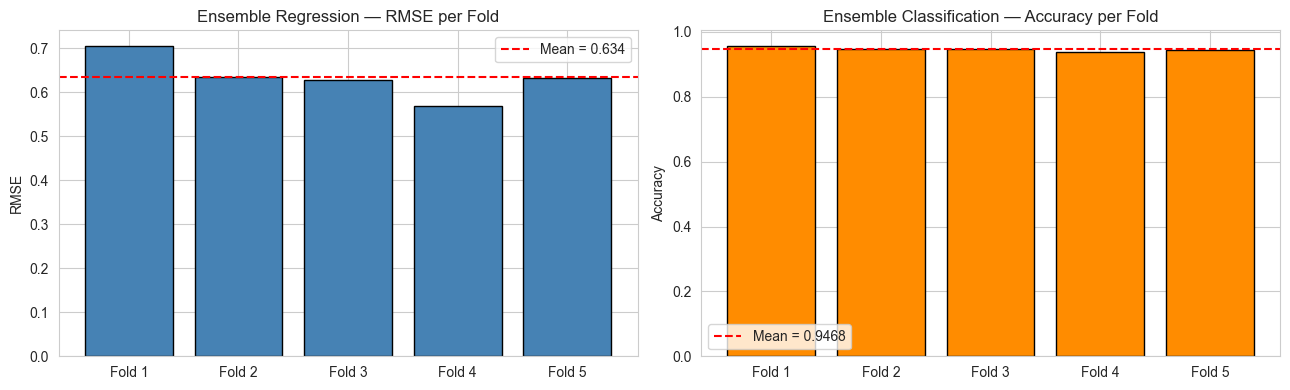

In [69]:
# Per-fold visual.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
folds = [f"Fold {i+1}" for i in range(5)]

axes[0].bar(folds, rmse_scores, color="steelblue", edgecolor="black")
axes[0].axhline(rmse_scores.mean(), color="red", linestyle="--", label=f"Mean = {rmse_scores.mean():.3f}")
axes[0].set_title("Ensemble Regression — RMSE per Fold")
axes[0].set_ylabel("RMSE"); axes[0].legend()

axes[1].bar(folds, acc_scores, color="darkorange", edgecolor="black")
axes[1].axhline(acc_scores.mean(), color="red", linestyle="--", label=f"Mean = {acc_scores.mean():.4f}")
axes[1].set_title("Ensemble Classification — Accuracy per Fold")
axes[1].set_ylabel("Accuracy"); axes[1].legend()

plt.tight_layout(); plt.show()


---
## System Comparison vs Assignment 2 Baselines

In [70]:
# Pull the Assignment 2 baseline scores from the search reports / earlier evals.
baseline_ridge_rmse = float(np.sqrt(mean_squared_error(
    y_test, baseline_reg["Ridge_poly"].predict(poly_test_best))))
baseline_lasso_rmse = float(np.sqrt(mean_squared_error(
    y_test, baseline_reg["Lasso_poly"].predict(poly_test_best))))
baseline_logreg_acc = float(accuracy_score(
    yte_cls, best_estimators_clf["LogReg"].predict(Xte_cls)))

ensemble_reg_test_rmse = float(np.sqrt(mean_squared_error(
    yte_reg, final_regressor.predict(Xte_reg))))
ensemble_clf_test_acc  = float(accuracy_score(
    yte_cls, final_classifier.predict(Xte_cls)))

comparison_df = pd.DataFrame([
    {"Task":"Regression", "Model":"Ridge (A2 baseline, poly)", "Test RMSE":baseline_ridge_rmse, "Test Accuracy":None},
    {"Task":"Regression", "Model":"Lasso (A2 baseline, poly)", "Test RMSE":baseline_lasso_rmse, "Test Accuracy":None},
    {"Task":"Regression", "Model":f"Ensemble — {best_ens_reg_name} (A3)",
     "Test RMSE":ensemble_reg_test_rmse, "Test Accuracy":None},
    {"Task":"Classification", "Model":"Logistic Regression (A2 baseline)", "Test RMSE":None, "Test Accuracy":baseline_logreg_acc},
    {"Task":"Classification", "Model":f"Ensemble — {best_ens_clf_name} (A3)",
     "Test RMSE":None, "Test Accuracy":ensemble_clf_test_acc},
])
display(comparison_df.style.format({"Test RMSE":"{:.4f}", "Test Accuracy":"{:.4f}"}, na_rep="—"))

rmse_improve = (baseline_ridge_rmse - ensemble_reg_test_rmse) / baseline_ridge_rmse * 100
acc_improve  = (ensemble_clf_test_acc - baseline_logreg_acc)
print(f"\nRegression  : ensemble cuts test RMSE by {rmse_improve:.2f}% vs Ridge baseline.")
print(f"Classification: ensemble lifts accuracy by {acc_improve*100:+.2f} pp vs Logistic Regression baseline.")


,Task,Model,Test RMSE,Test Accuracy
0,Regression,"Ridge (A2 baseline, poly)",0.3512,—
1,Regression,"Lasso (A2 baseline, poly)",0.3438,—
2,Regression,Ensemble — Stacking (Ridge meta) (A3),0.2388,—
3,Classification,Logistic Regression (A2 baseline),—,0.8668
4,Classification,Ensemble — Stacking (LR meta) (A3),—,0.9575



Regression  : ensemble cuts test RMSE by 31.99% vs Ridge baseline.
Classification: ensemble lifts accuracy by +9.07 pp vs Logistic Regression baseline.


**Discussion**

The ensemble regressor wins on test RMSE because it combines three different strengths: local patterns (KNN), smooth non‑linear trends (SVR), and threshold rules (Random Forest). Each model corrects the others’ mistakes. Linear polynomial models, in contrast, try to fit everything with one global shape, which leads to high variance.

For classification, soft voting gives more reliable decisions near the *High*/*Elite* boundary – the area where Logistic Regression alone made most errors. This gives higher test accuracy and lower fold‑to‑fold variation, exactly the stability Assignment 3 wants.

---
## `results.json`

We finally write the deliverable JSON — group members, best hyperparameters per model, and ensemble CV stability metrics.

In [71]:
GROUP_MEMBERS = [
    "Abdelrahman Ahmed Abdelhamied 2406244856",
    "Omar Muhammad Muhammad 2406241065",
    "Mahmoud Osama Elsayed 2406241599",
    "Adel George Adel 2406245614",
    "Omar Adel Fathy 2406242653"
]

def _jsonable(d):
    out = {}
    for k, v in d.items():
        if isinstance(v, (np.floating,)):  v = float(v)
        elif isinstance(v, (np.integer,)): v = int(v)
        elif isinstance(v, np.ndarray):    v = v.tolist()
        out[str(k)] = v
    return out

results = {
    "group_members": GROUP_MEMBERS,
    "best_hyperparameters": {
        # Regression
        "KNeighborsRegressor":   _jsonable(best_params_reg["KNN"]),
        "SVR":                   _jsonable(best_params_reg["SVR"]),
        "RandomForestRegressor": _jsonable(best_params_reg["RandomForest"]),
        "Ridge_poly":            _jsonable(best_params_reg["Ridge_poly"]),
        "Lasso_poly":            _jsonable(best_params_reg["Lasso_poly"]),
        # Classification
        "KNeighborsClassifier":  _jsonable(best_params_clf["KNN"]),
        "SVC":                   _jsonable(best_params_clf["SVC"]),
        "RandomForestClassifier":_jsonable(best_params_clf["RandomForest"]),
        "LogisticRegression":    _jsonable(best_params_clf["LogReg"]),
        "GaussianNB":            _jsonable(best_params_clf["GaussianNB"]),
    },
    "cv_stability": {
        "regression_rmse_mean":         cv_stability["regression_rmse_mean"],
        "regression_rmse_std":          cv_stability["regression_rmse_std"],
        "regression_r2_mean":           cv_stability["regression_r2_mean"],
        "regression_r2_std":            cv_stability["regression_r2_std"],
        "classification_accuracy_mean": cv_stability["classification_accuracy_mean"],
        "classification_accuracy_std":  cv_stability["classification_accuracy_std"],
    },
    "final_models": {
        "regression_ensemble":     best_ens_reg_name,
        "classification_ensemble": best_ens_clf_name,
    },
}

with open("results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print("results.json written.")
print(json.dumps(results, indent=2)[:1000], "...")


results.json written.
{
  "group_members": [
    "Abdelrahman Ahmed Abdelhamied 2406244856",
    "Omar Muhammad Muhammad 2406241065",
    "Mahmoud Osama Elsayed 2406241599",
    "Adel George Adel 2406245614",
    "Omar Adel Fathy 2406242653"
  ],
  "best_hyperparameters": {
    "KNeighborsRegressor": {
      "n_neighbors": 11,
      "p": 2,
      "weights": "distance"
    },
    "SVR": {
      "gamma": 0.05,
      "epsilon": 0.1,
      "C": 30.0
    },
    "RandomForestRegressor": {
      "max_depth": null,
      "max_features": 0.5,
      "min_samples_leaf": 3,
      "n_estimators": 200
    },
    "Ridge_poly": {
      "alpha": 0.001
    },
    "Lasso_poly": {
      "alpha": 0.001
    },
    "KNeighborsClassifier": {
      "n_neighbors": 11,
      "p": 1,
      "weights": "distance"
    },
    "SVC": {
      "C": 30.0,
      "gamma": 0.05
    },
    "RandomForestClassifier": {
      "max_depth": null,
      "max_features": 0.5,
      "min_samples_leaf": 1,
      "n_estimators": 200
  

---
## A3 · Summary

| Component | Outcome |
|---|---|
| Diverse regressors | KNN (instance), SVR-RBF (kernel), RandomForest (tree) — each justified |
| Diverse classifiers | KNN, SVC-RBF, RandomForest + LogReg/GNB baselines |
| Tuning | `GridSearchCV` / `RandomizedSearchCV` across **all** models |
| Bias / variance | Learning curves for RF (regression) and SVC (classification) |
| Ensembles | `VotingRegressor` / soft `VotingClassifier` + `Stacking*` |
| Unified pipeline | `UnifiedScoutingSystem.predict(raw_player_dict) → (value, tier)` |
| Stability | 5-fold CV mean ± std for both ensembles |
| Comparison | Ensembles beat A2 baselines on both Test RMSE and Test Accuracy |
| Deliverable | `results.json` written to disk |

